In [1]:
import pandas as pd
accidents = pd.read_csv("AccidentsBig.csv", low_memory=False)
vehicles = pd.read_csv("VehiclesBig.csv", low_memory=False)
casualties = pd.read_csv("CasualtiesBig.csv", low_memory=False)

print("Accidents shape:", accidents.shape)
print("Vehicles shape:", vehicles.shape)
print("Casualties shape:", casualties.shape)

Accidents shape: (608787, 30)
Vehicles shape: (964020, 22)
Casualties shape: (59998, 15)


In [2]:
print("Accidents columns:\n", accidents.columns)
print("Vehicles columns:\n", vehicles.columns)
print("Casualties columns:\n", casualties.columns)

Accidents columns:
 Index(['Accident_Index', 'longitude', 'latitude', 'Police_Force',
       'Accident_Severity', 'Number_of_Vehicles', 'Number_of_Casualties',
       'Day_of_Week', 'Time', 'Local_Authority_(District)',
       'Local_Authority_(Highway)', '1st_Road_Class', '1st_Road_Number',
       'Road_Type', 'Speed_limit', 'Junction_Detail', 'Junction_Control',
       '2nd_Road_Class', '2nd_Road_Number',
       'Pedestrian_Crossing-Human_Control',
       'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions',
       'Weather_Conditions', 'Road_Surface_Conditions',
       'Special_Conditions_at_Site', 'Carriageway_Hazards',
       'Urban_or_Rural_Area', 'Did_Police_Officer_Attend_Scene_of_Accident',
       'LSOA_of_Accident_Location', 'Date'],
      dtype='object')
Vehicles columns:
 Index(['Accident_Index', 'Vehicle_Reference', 'Vehicle_Type',
       'Towing_and_Articulation', 'Vehicle_Manoeuvre',
       'Vehicle_Location-Restricted_Lane', 'Junction_Location',
       'Skiddin

In [3]:
# Start with CASUALTIES (MAIN DATASET)
full_data = casualties.copy()

# Merge with Accidents
full_data = pd.merge(full_data, accidents, on="Accident_Index", how="left")

# Merge with Vehicles
full_data = pd.merge(full_data, vehicles, on="Accident_Index", how="left")

print("Final Shape:", full_data.shape)

Final Shape: (59998, 65)


In [4]:
print("Shape before preprocessing:", full_data.shape)

Shape before preprocessing: (59998, 65)


In [5]:
# Remove duplicate columns (_y)
full_data = full_data.loc[:, ~full_data.columns.duplicated()]

print("After removing duplicate columns:", full_data.shape)

After removing duplicate columns: (59998, 65)


In [6]:
missing = full_data.isnull().sum().sort_values(ascending=False)
print(missing.head(10))

LSOA_of_Accident_Location    97
Time                          1
Accident_Index                0
Casualty_Class                0
Vehicle_Reference_x           0
Age_of_Casualty               0
Age_Band_of_Casualty          0
Casualty_Severity             0
Casualty_Reference            0
Pedestrian_Movement           0
dtype: int64


In [7]:
num_cols = full_data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = full_data.select_dtypes(include=['object']).columns

In [8]:
for col in num_cols:
    full_data[col].fillna(full_data[col].median(), inplace=True)

/tmp/ipykernel_16877/444315489.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  full_data[col].fillna(full_data[col].median(), inplace=True)


In [9]:
for col in cat_cols:
    full_data[col].fillna(full_data[col].mode()[0], inplace=True)

/tmp/ipykernel_16877/2282635775.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  full_data[col].fillna(full_data[col].mode()[0], inplace=True)


In [10]:
print("Remaining missing values:", full_data.isnull().sum().sum())

Remaining missing values: 0


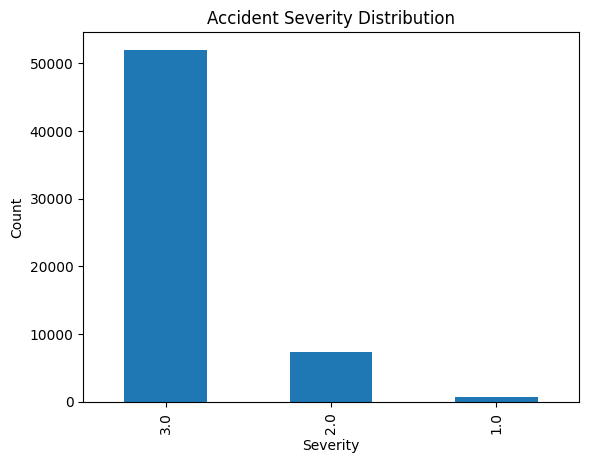

In [11]:
import matplotlib.pyplot as plt

full_data['Accident_Severity'].value_counts().plot(kind='bar')
plt.title("Accident Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.show()

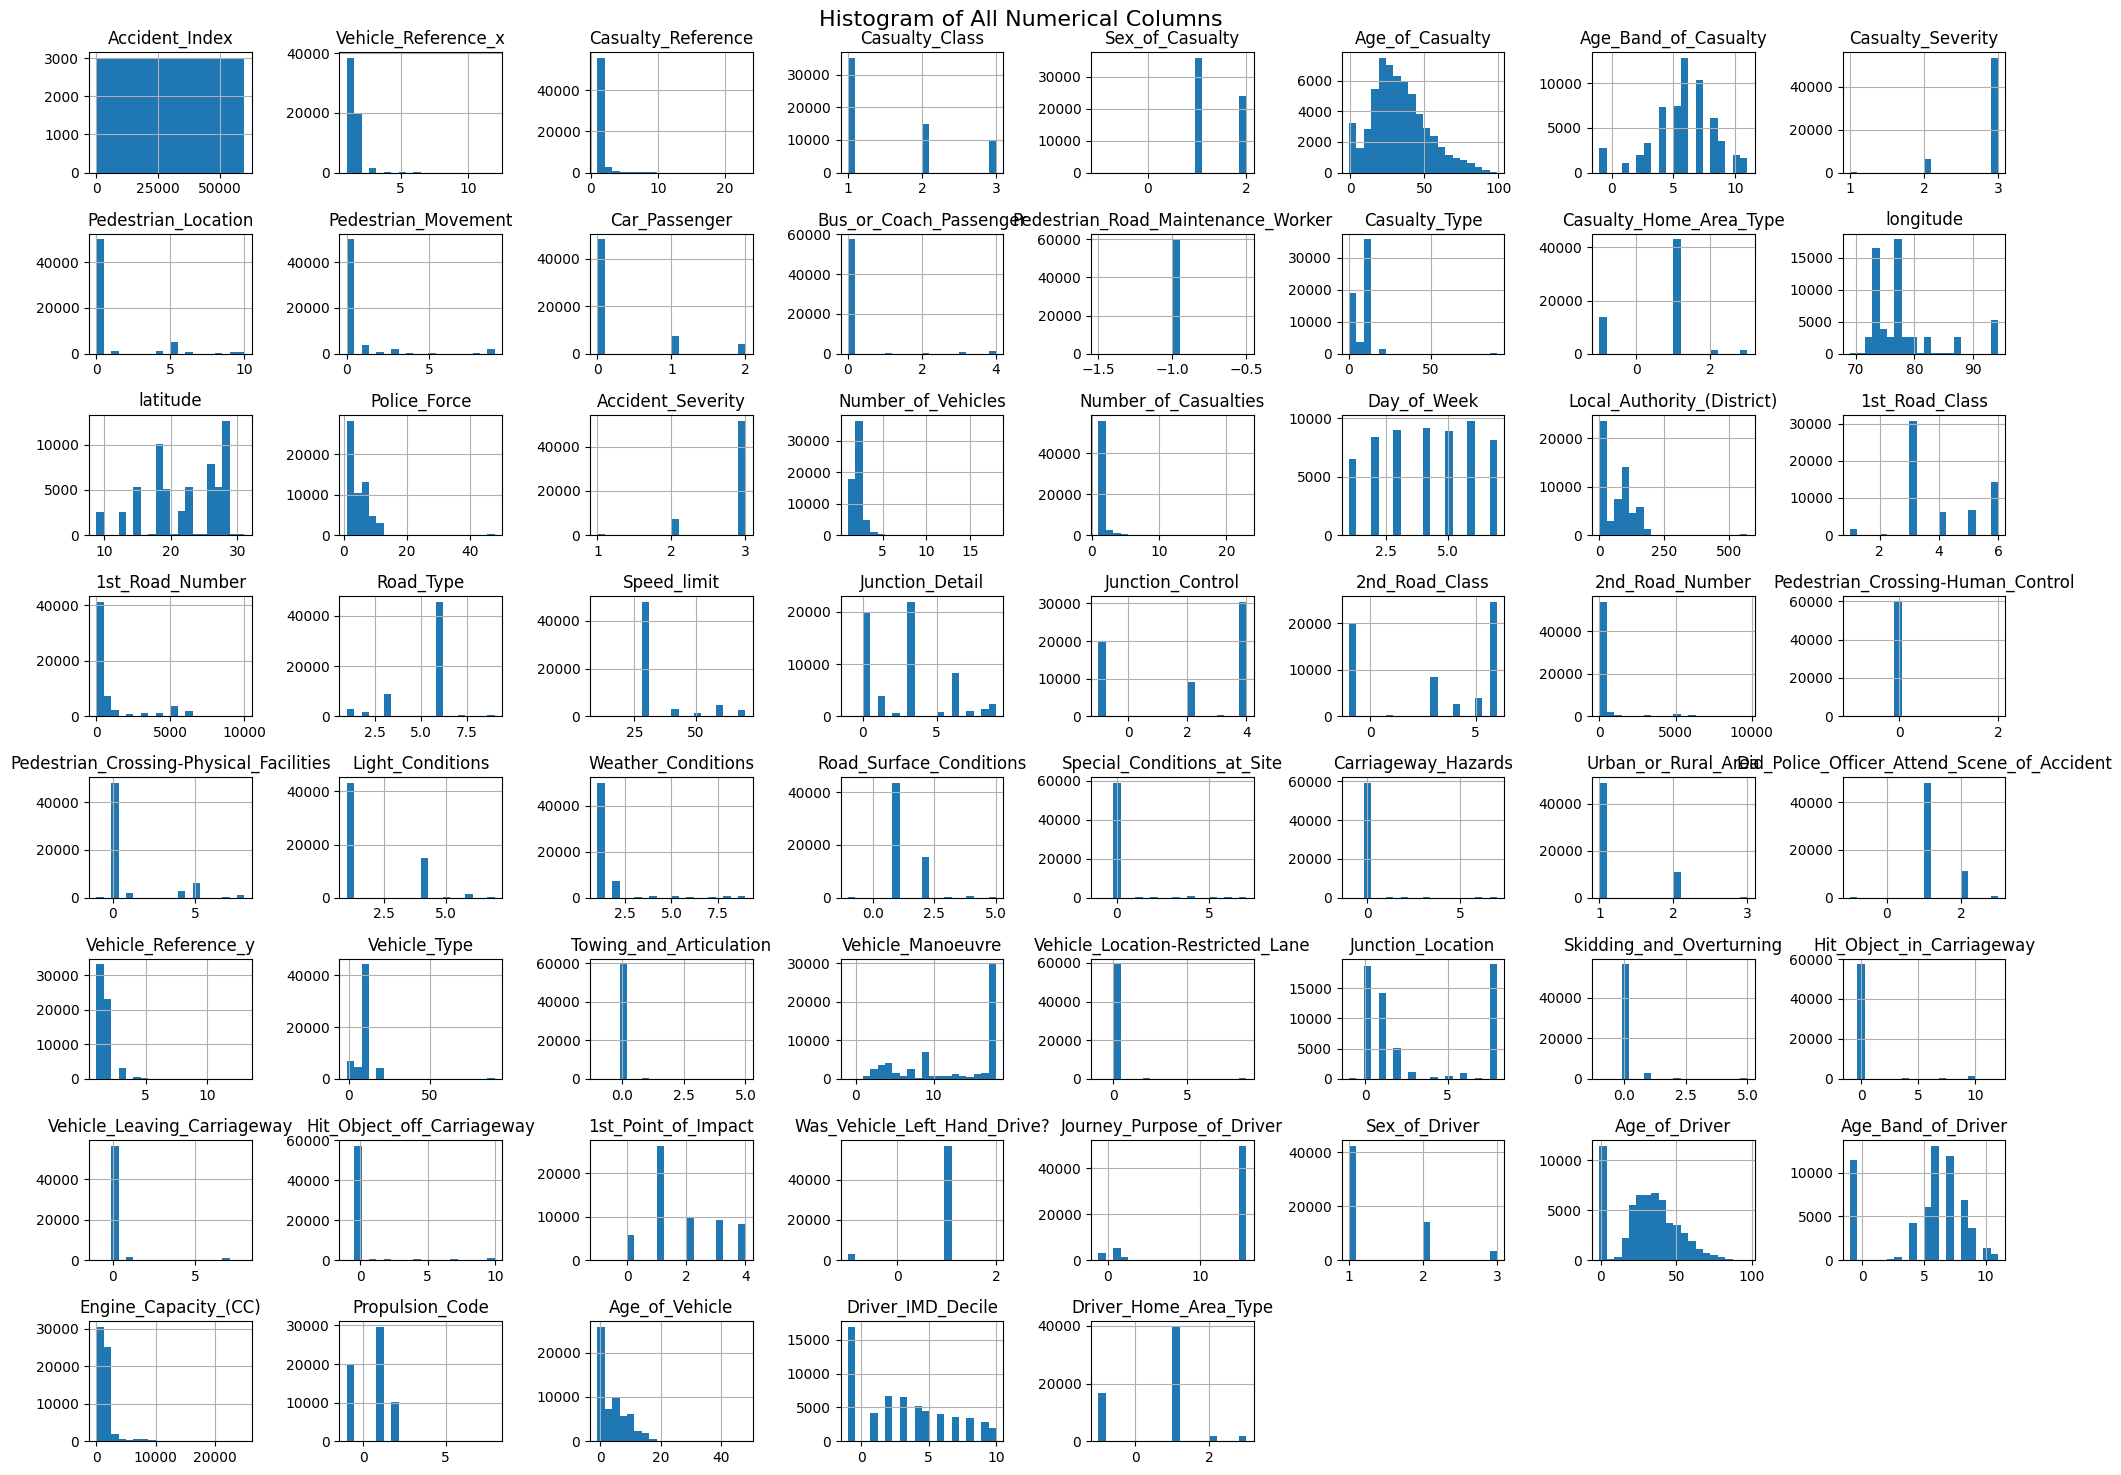

In [12]:
import matplotlib.pyplot as plt

# Select only numeric columns
num_cols = full_data.select_dtypes(include=['int64', 'float64']).columns

# Plot all histograms in one go
full_data[num_cols].hist(bins=20, figsize=(20, 15))

plt.suptitle("Histogram of All Numerical Columns", fontsize=16)
plt.tight_layout()
plt.show()

In [13]:
full_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59998 entries, 0 to 59997
Data columns (total 65 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Accident_Index                               59998 non-null  int64  
 1   Vehicle_Reference_x                          59998 non-null  int64  
 2   Casualty_Reference                           59998 non-null  int64  
 3   Casualty_Class                               59998 non-null  int64  
 4   Sex_of_Casualty                              59998 non-null  int64  
 5   Age_of_Casualty                              59998 non-null  int64  
 6   Age_Band_of_Casualty                         59998 non-null  int64  
 7   Casualty_Severity                            59998 non-null  int64  
 8   Pedestrian_Location                          59998 non-null  int64  
 9   Pedestrian_Movement                          59998 non-null  int64  
 10

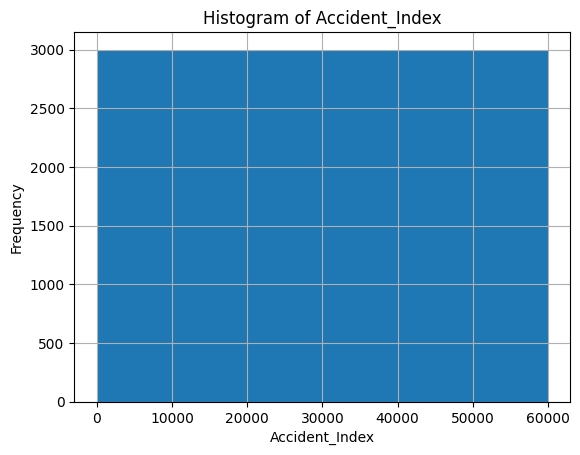

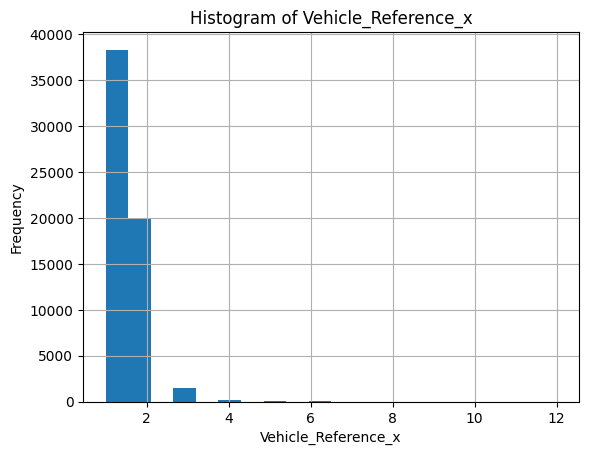

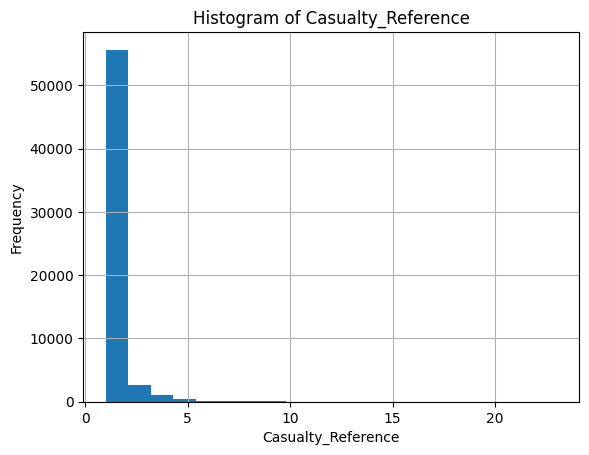

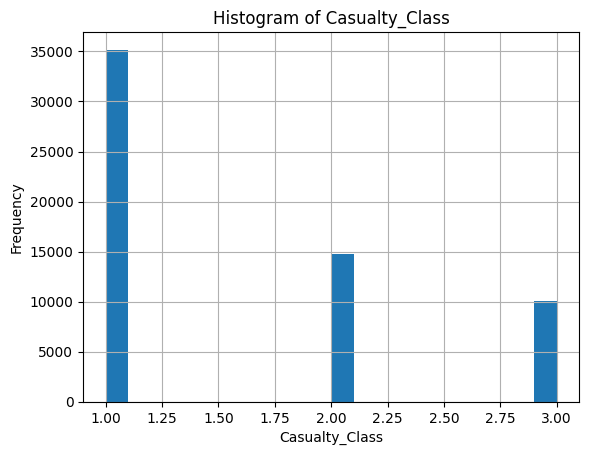

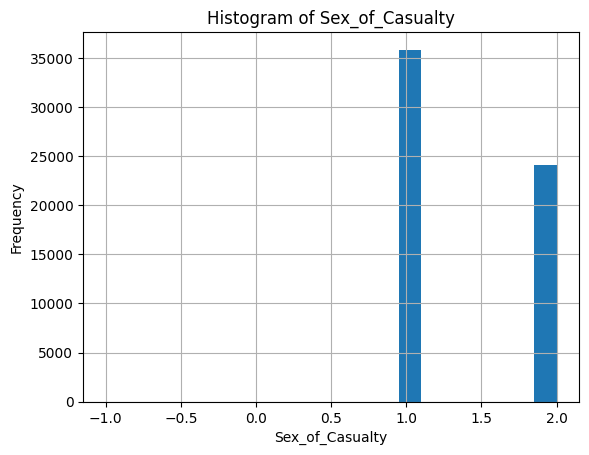

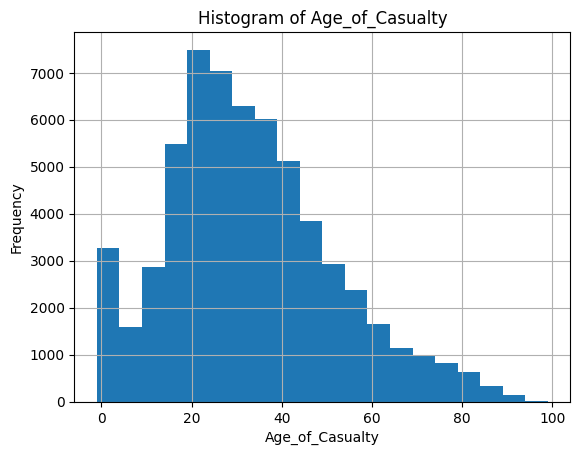

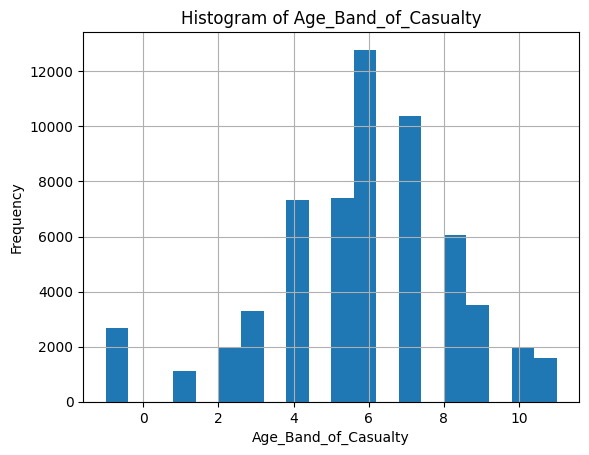

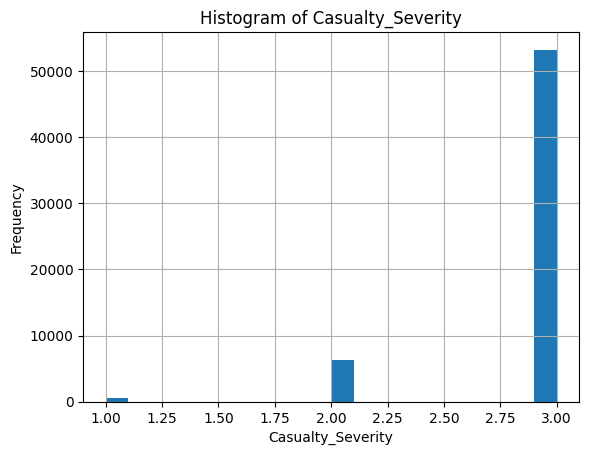

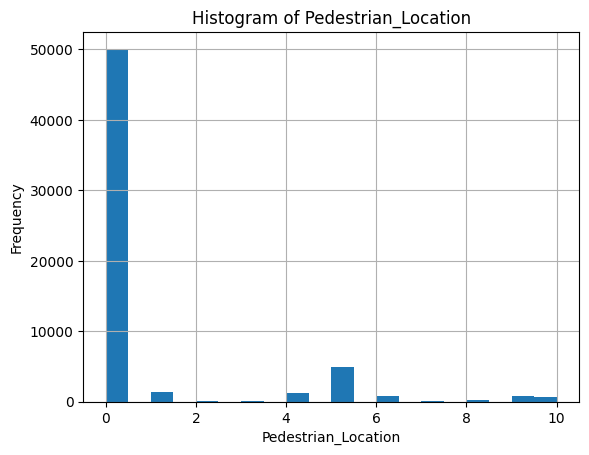

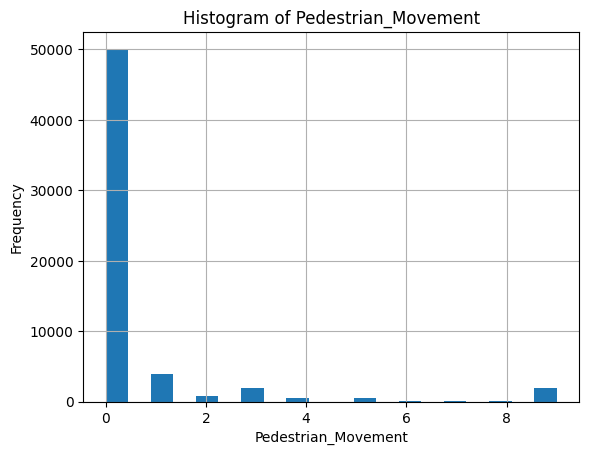

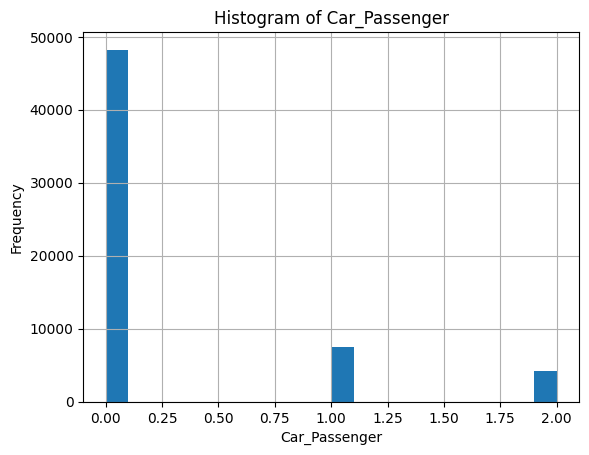

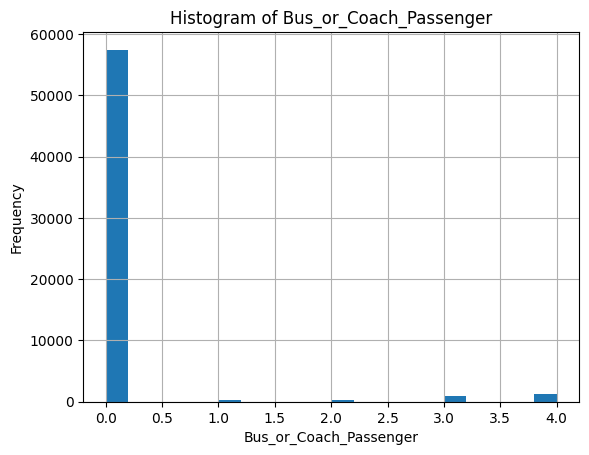

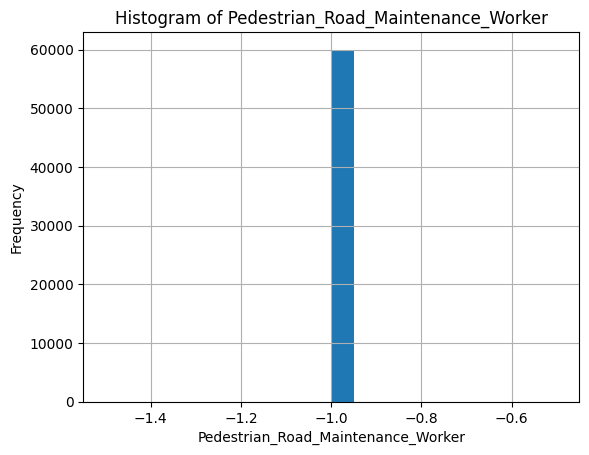

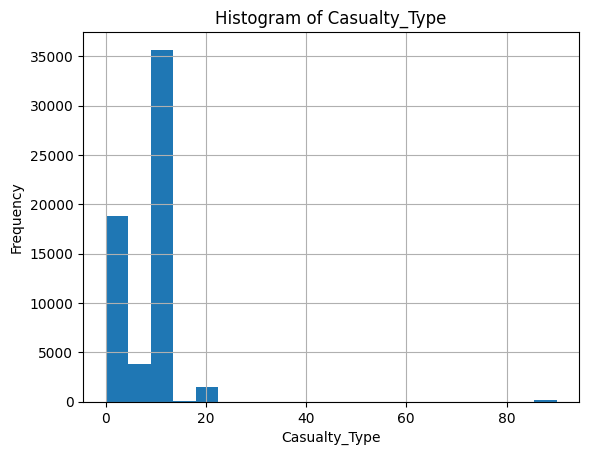

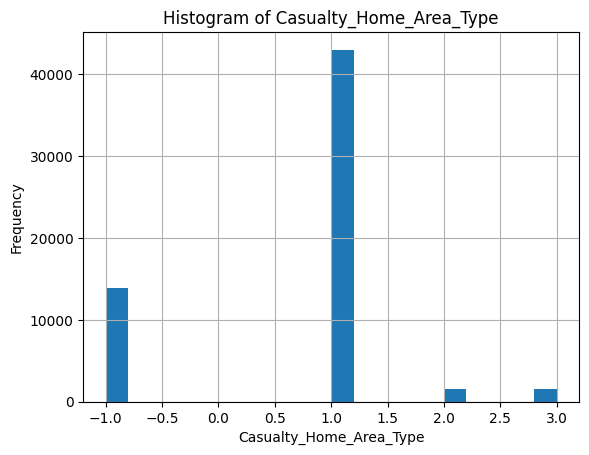

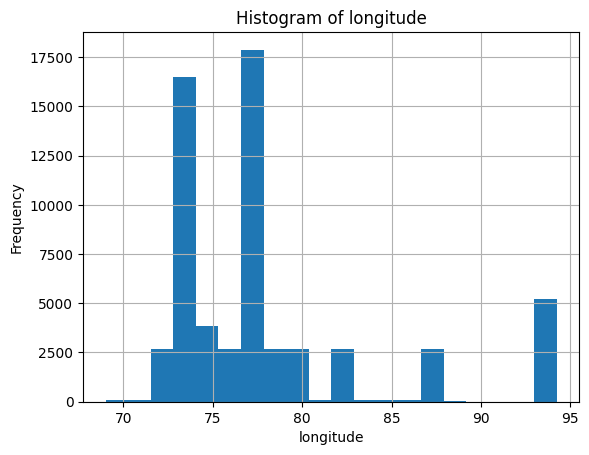

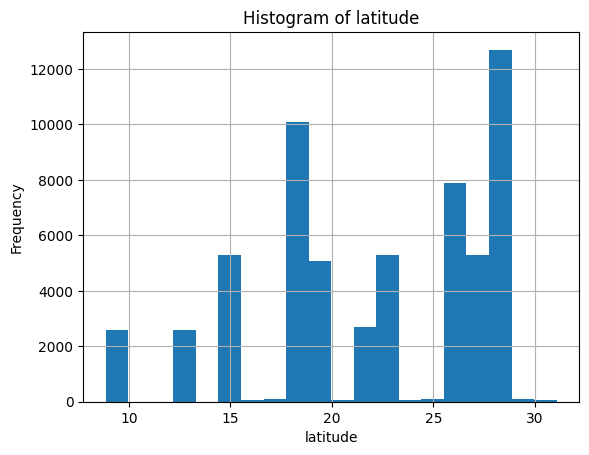

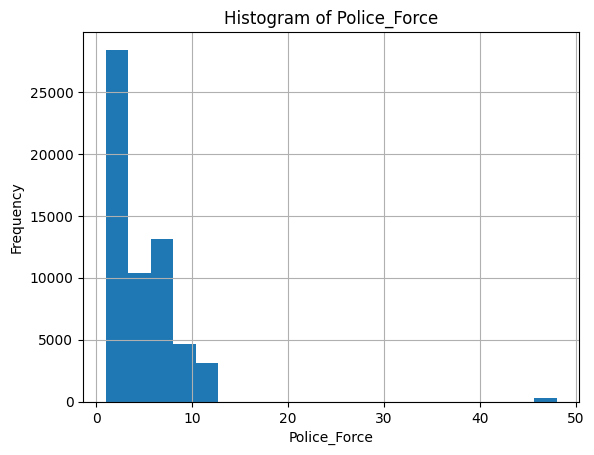

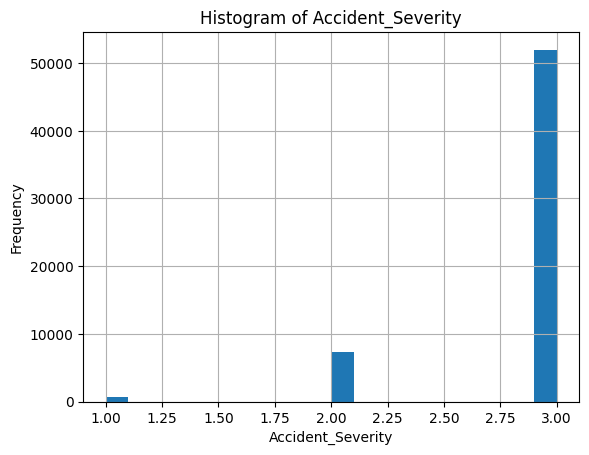

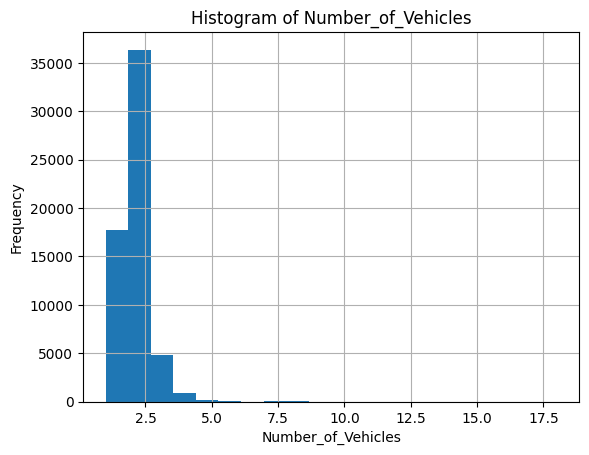

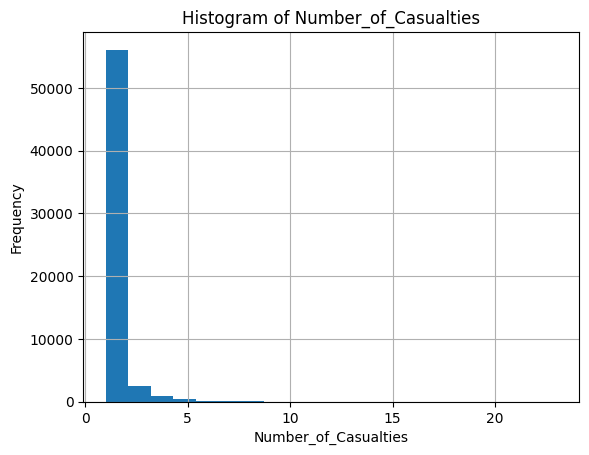

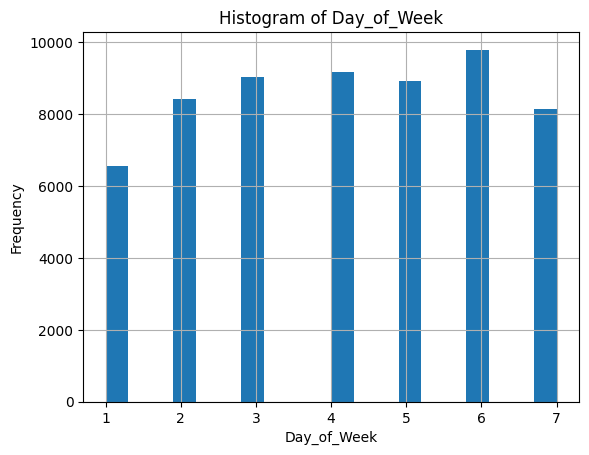

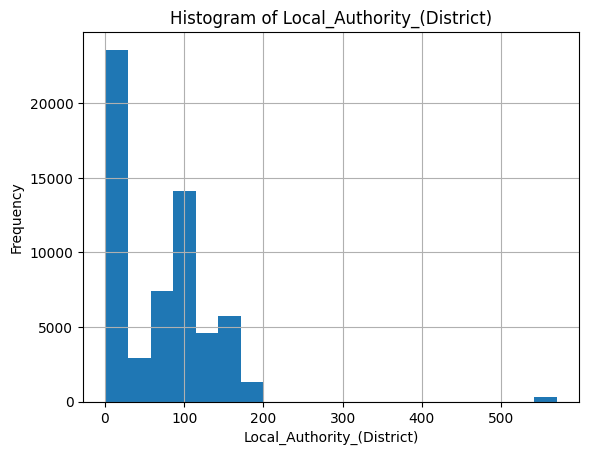

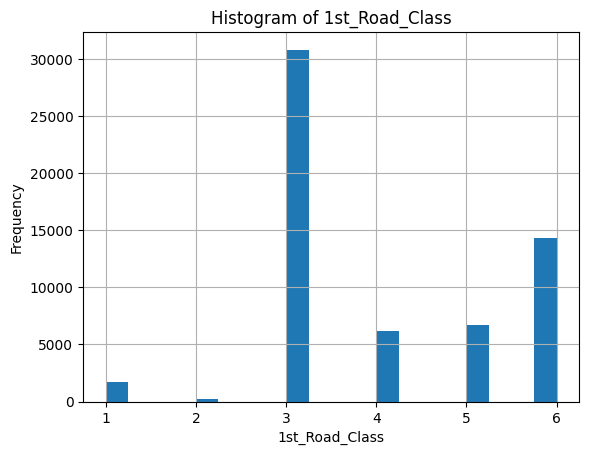

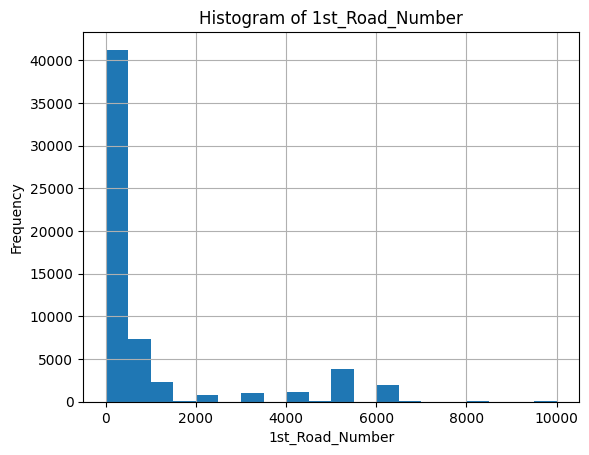

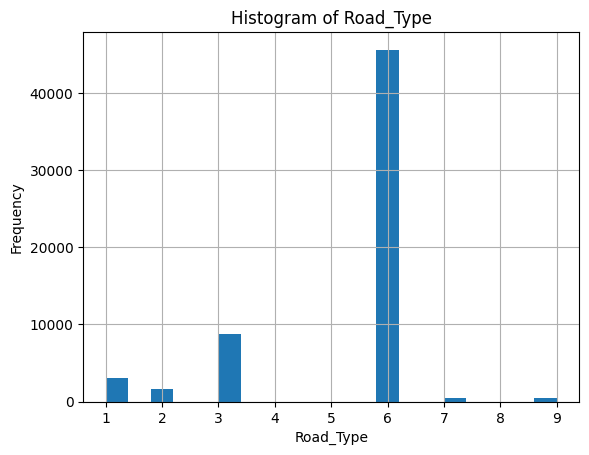

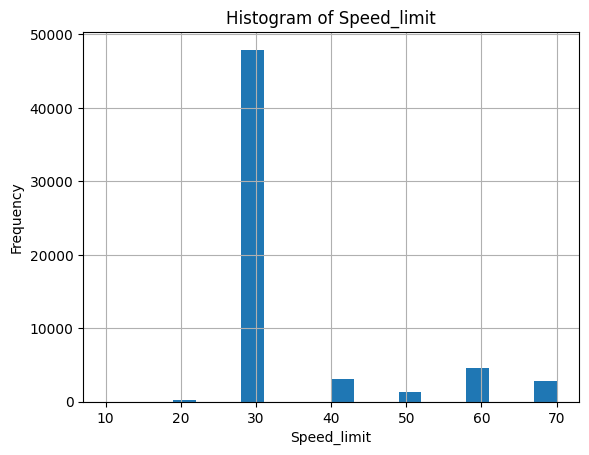

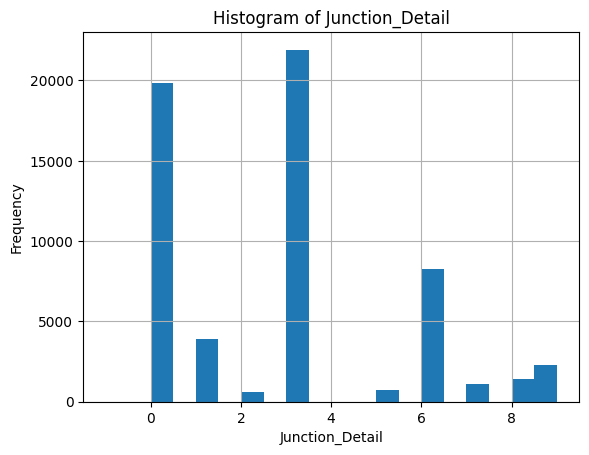

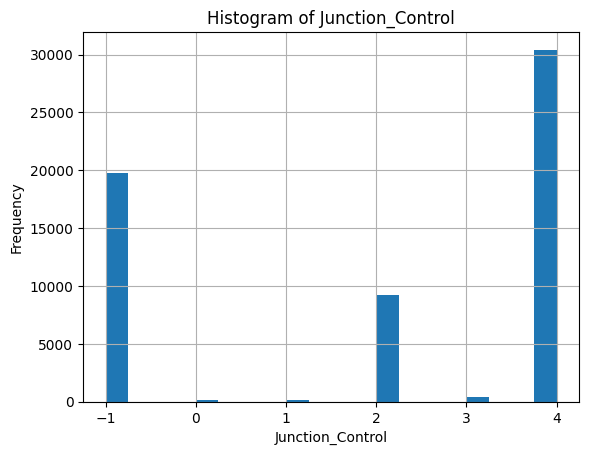

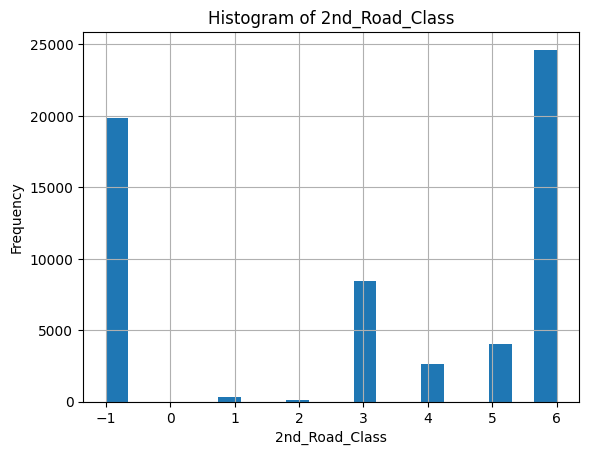

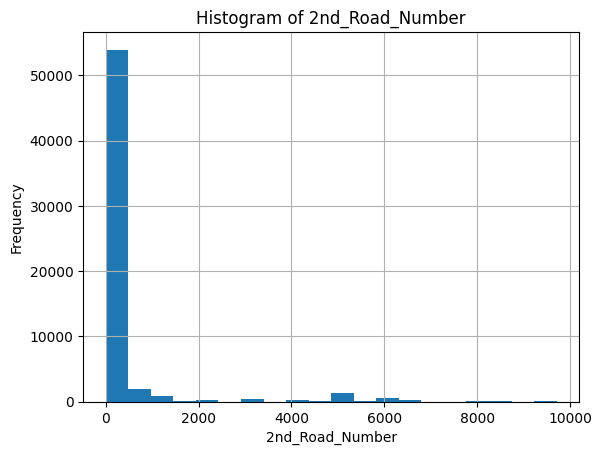

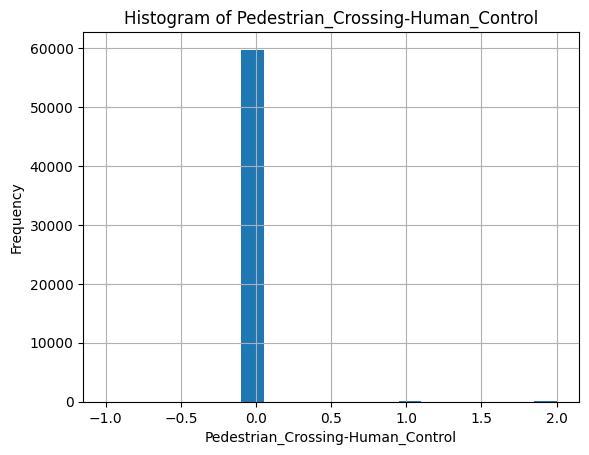

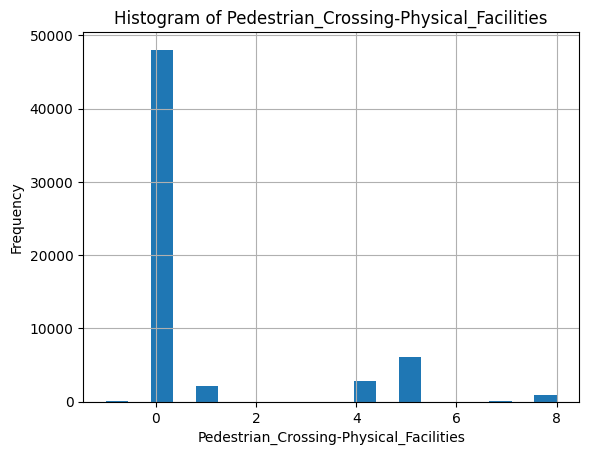

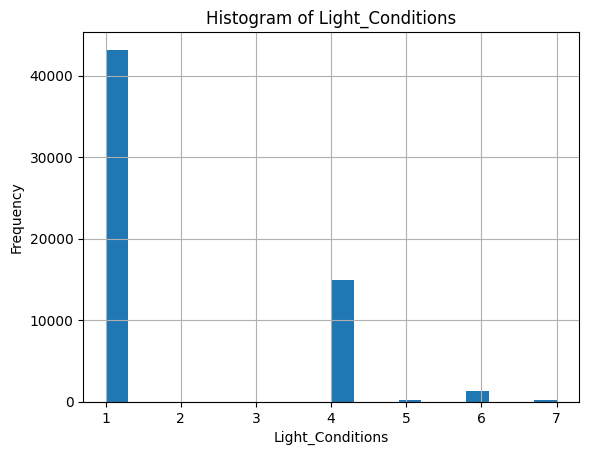

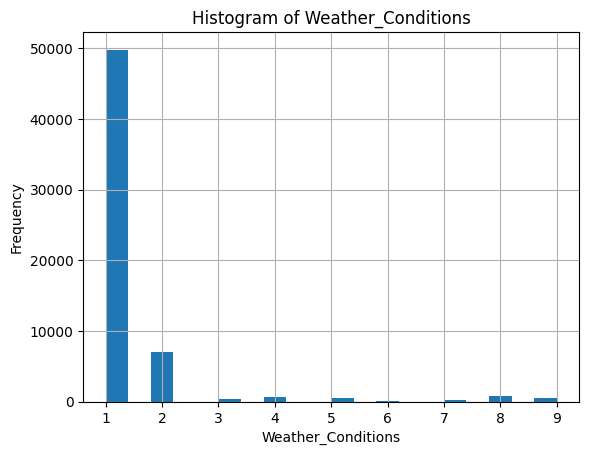

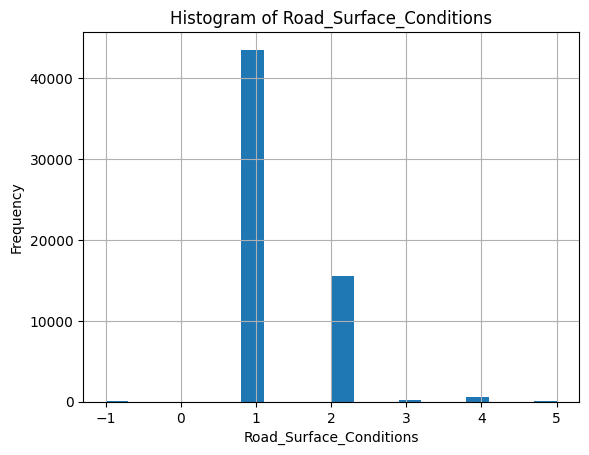

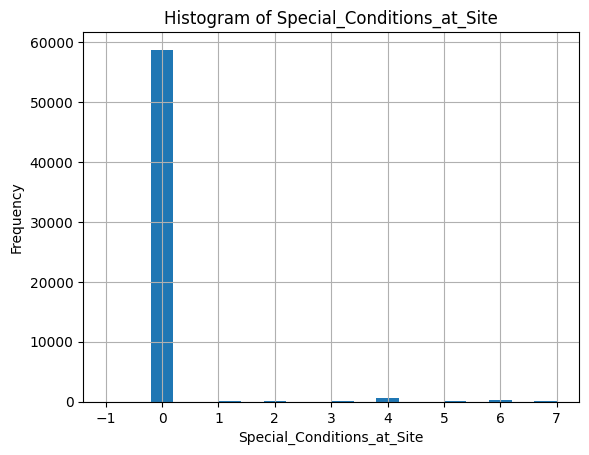

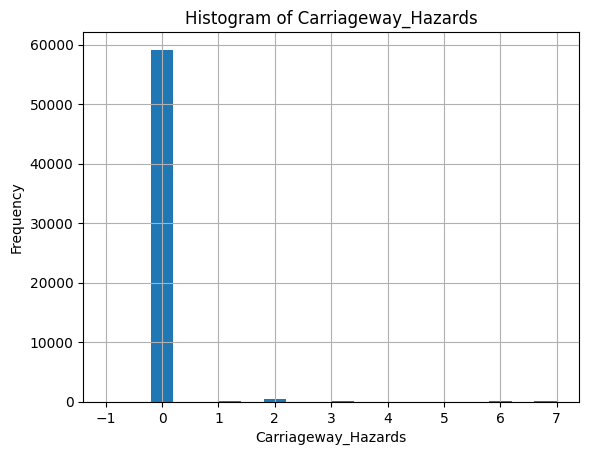

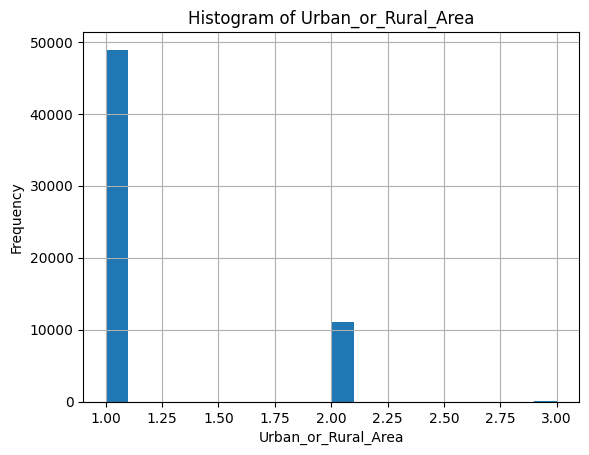

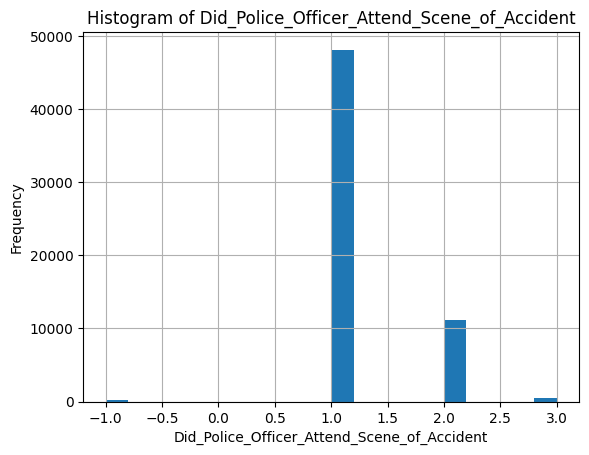

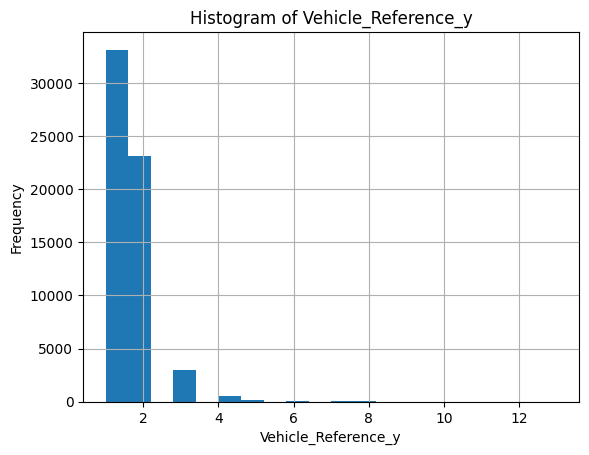

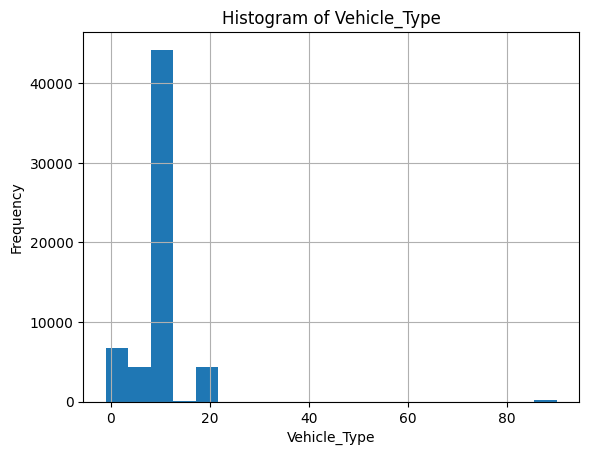

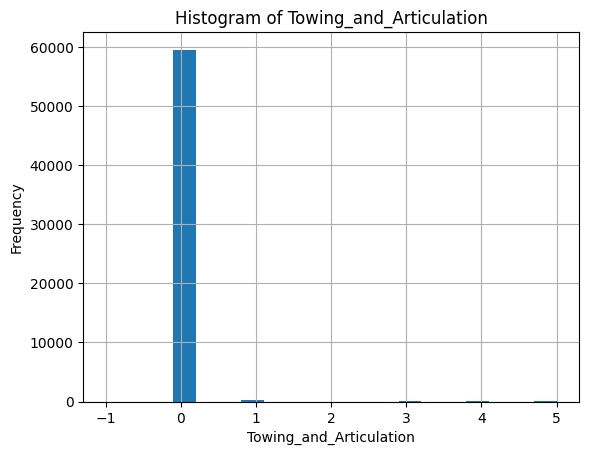

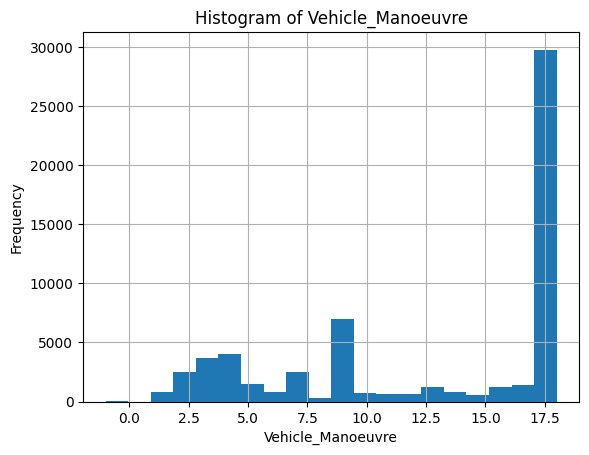

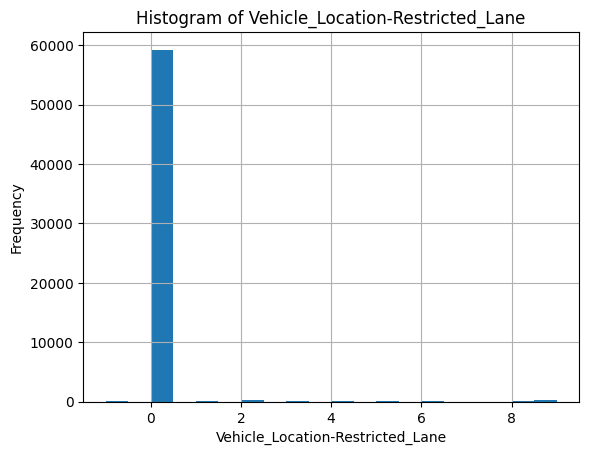

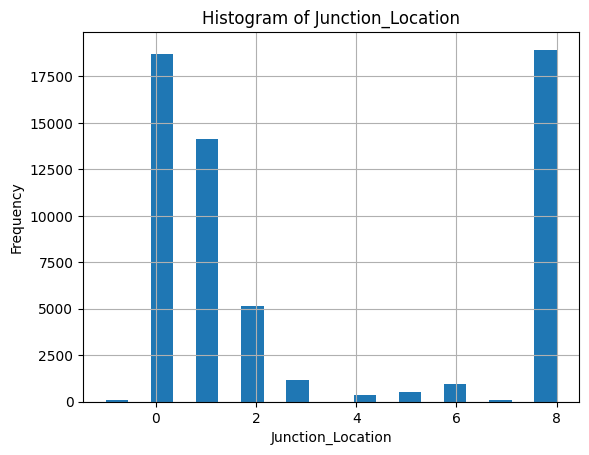

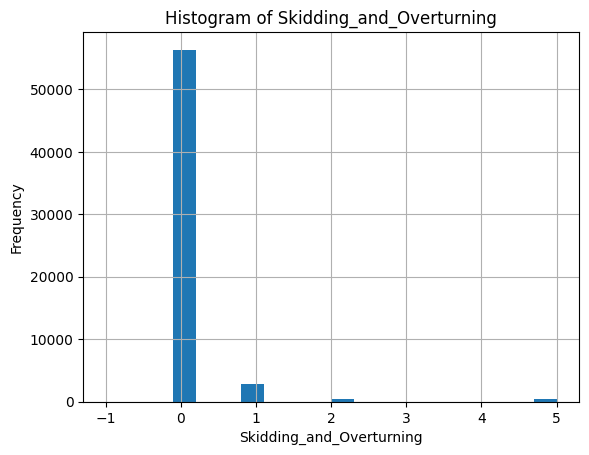

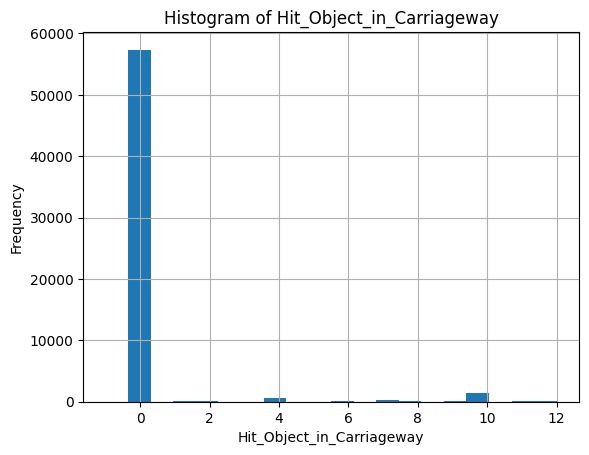

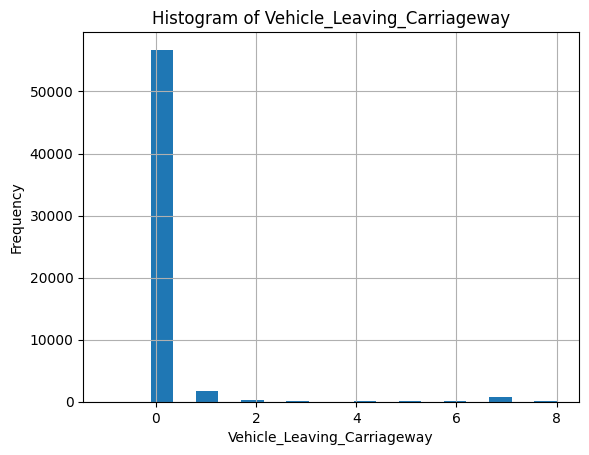

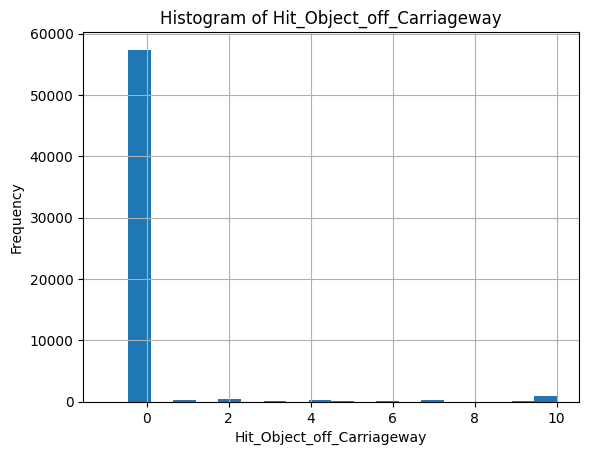

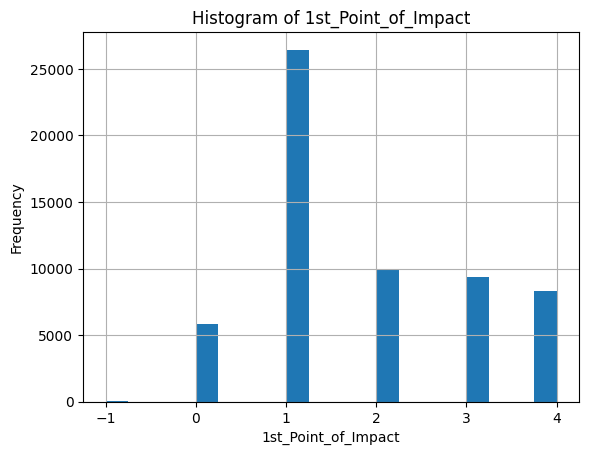

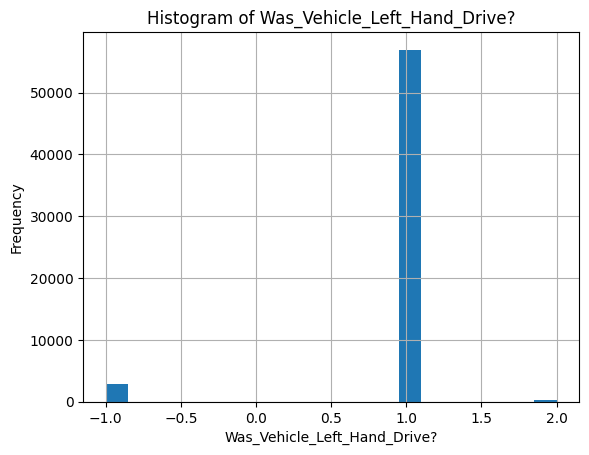

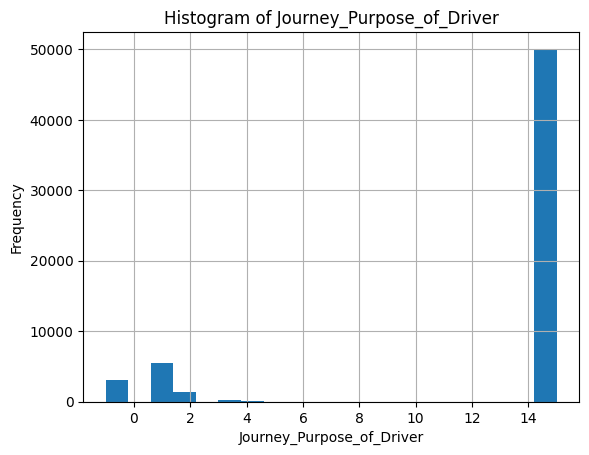

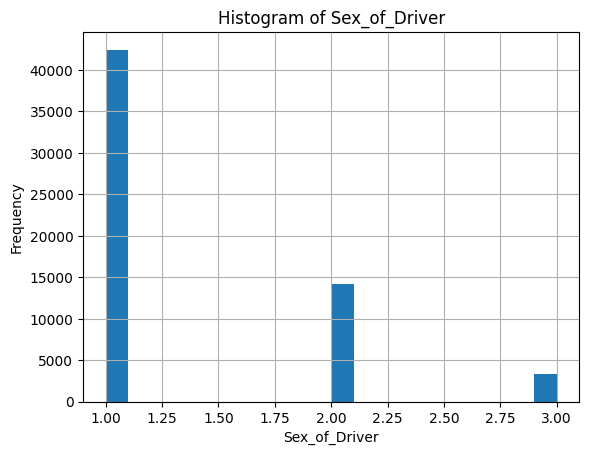

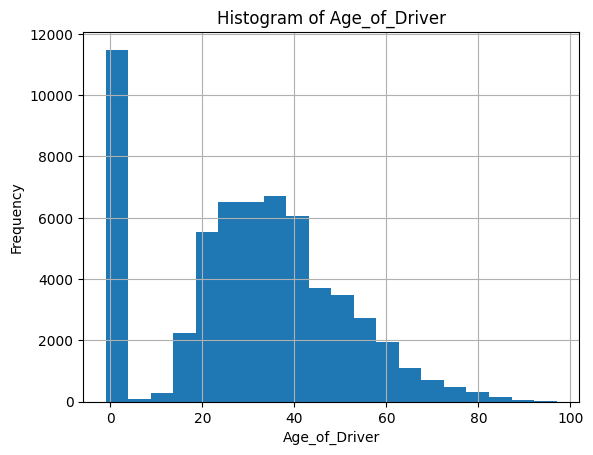

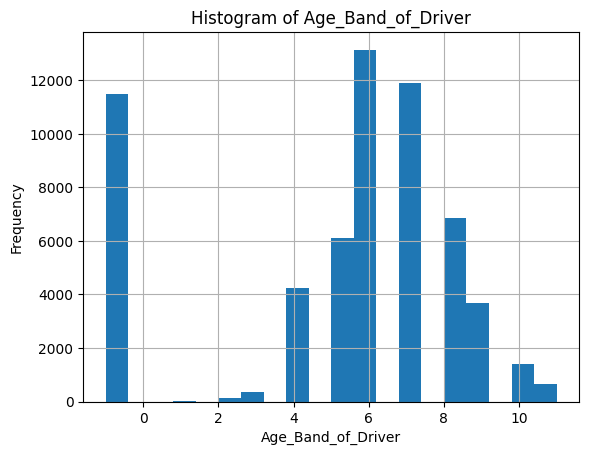

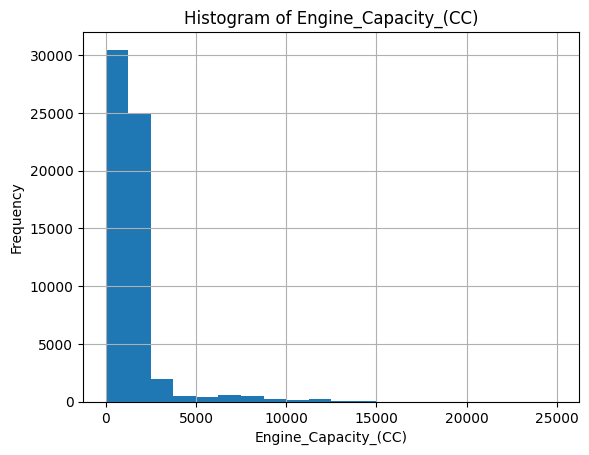

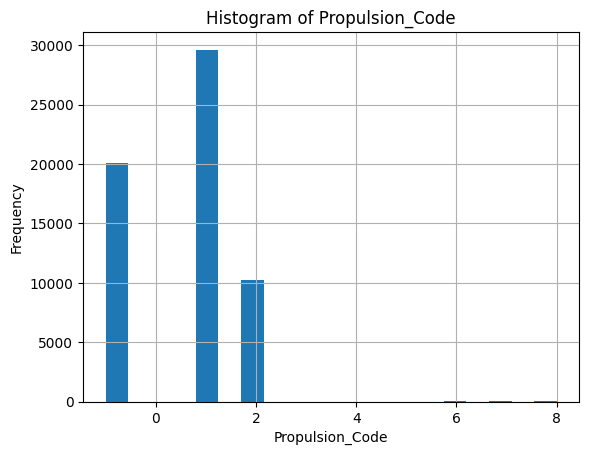

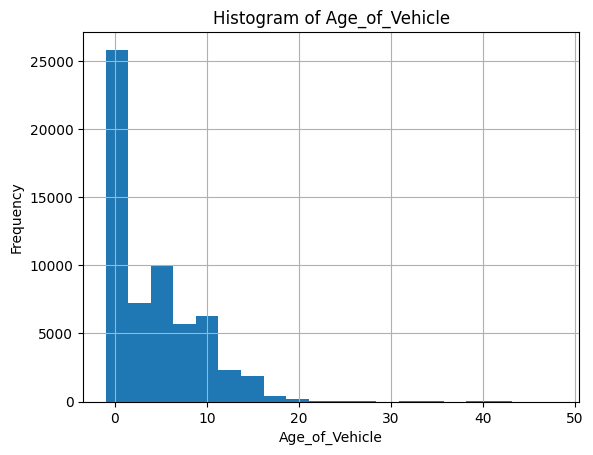

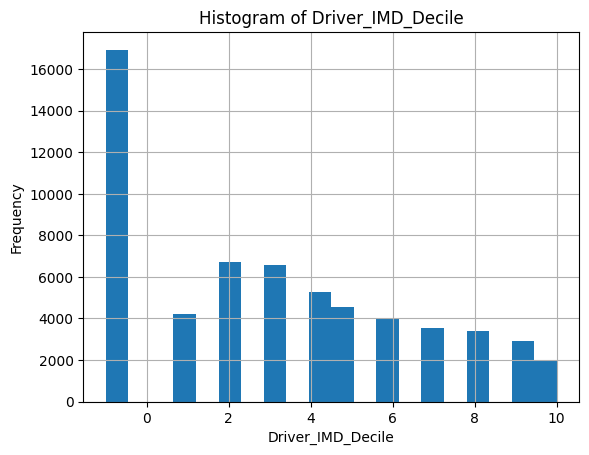

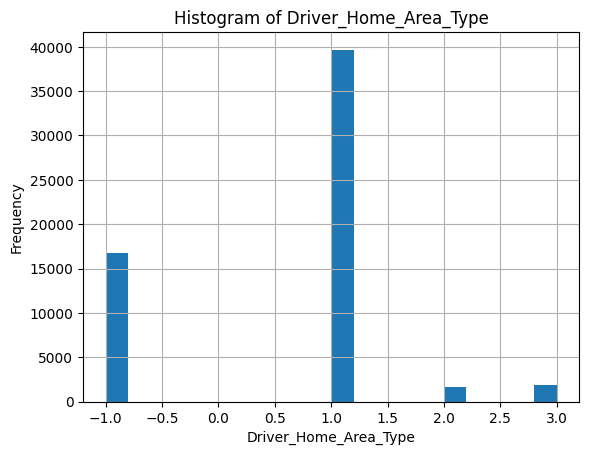

In [14]:
for col in num_cols:
    plt.figure()
    full_data[col].hist(bins=20)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

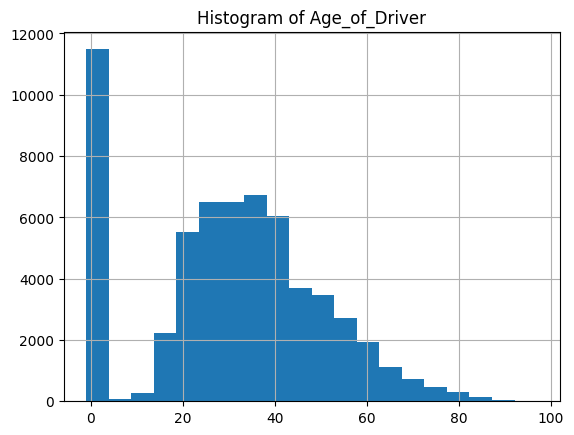

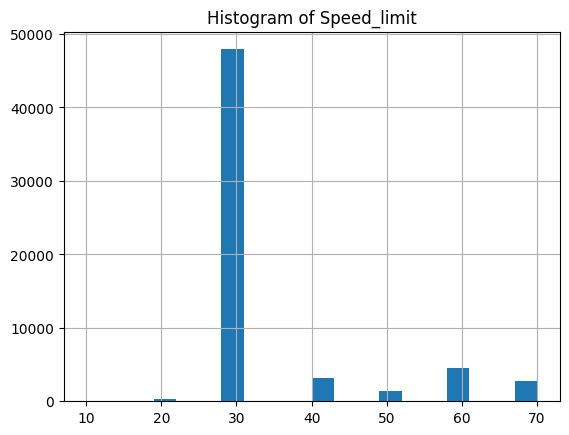

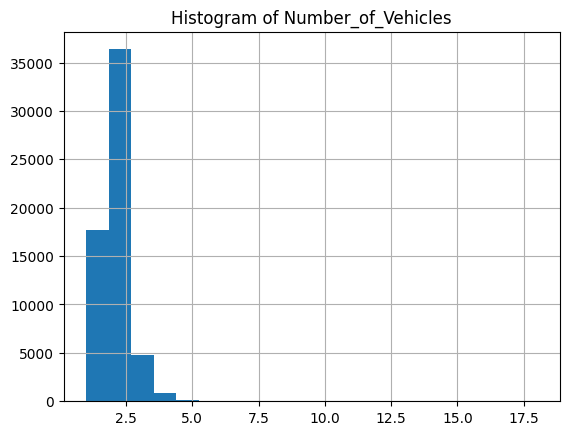

In [15]:
important_cols = ['Age_of_Driver', 'Speed_limit', 'Number_of_Vehicles']

for col in important_cols:
    plt.figure()
    full_data[col].hist(bins=20)
    plt.title(f"Histogram of {col}")
    plt.show()

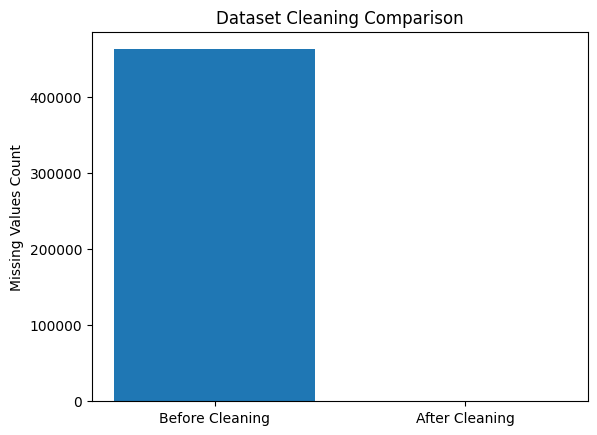

In [16]:
import matplotlib.pyplot as plt

# Manually set values
before_missing = 462128   # your earlier value
after_missing = 0         # after preprocessing

labels = ['Before Cleaning', 'After Cleaning']
values = [before_missing, after_missing]

plt.bar(labels, values)
plt.title("Dataset Cleaning Comparison")
plt.ylabel("Missing Values Count")
plt.show()

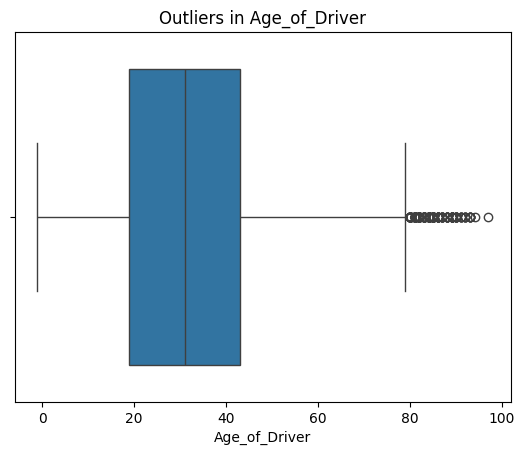

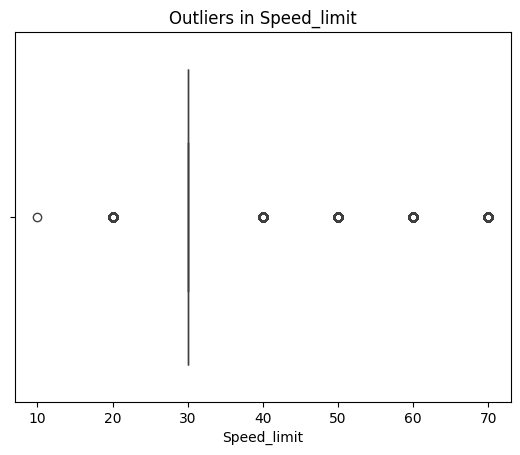

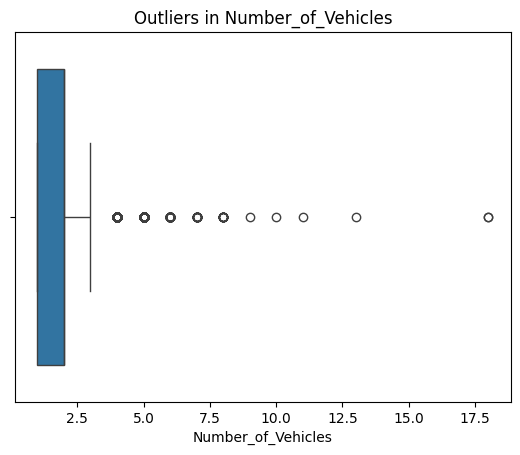

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['Age_of_Driver', 'Speed_limit', 'Number_of_Vehicles']

for col in cols:
    if col in full_data.columns:
        plt.figure()
        sns.boxplot(x=full_data[col])
        plt.title(f"Outliers in {col}")
        plt.show()

In [18]:
import numpy as np

for col in cols:
    if col in full_data.columns:
        Q1 = full_data[col].quantile(0.25)
        Q3 = full_data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = full_data[(full_data[col] < lower) | (full_data[col] > upper)]

        print(f"{col} - Number of outliers:", outliers.shape[0])

Age_of_Driver - Number of outliers: 362
Speed_limit - Number of outliers: 12073
Number_of_Vehicles - Number of outliers: 1177


In [19]:
import numpy as np

cols = ['Age_of_Driver', 'Speed_limit', 'Number_of_Vehicles']

for col in cols:
    if col in full_data.columns:
        Q1 = full_data[col].quantile(0.25)
        Q3 = full_data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        full_data[col] = np.clip(full_data[col], lower, upper)

print("Outliers handled using capping")

Outliers handled using capping


In [20]:
before_data = full_data.copy()
after_data = full_data.copy()

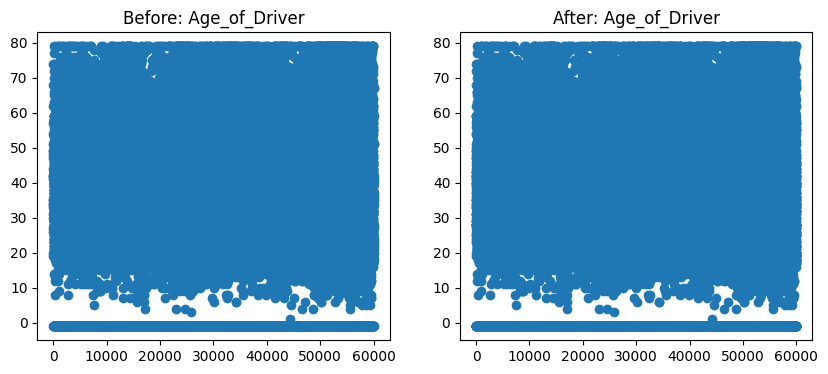

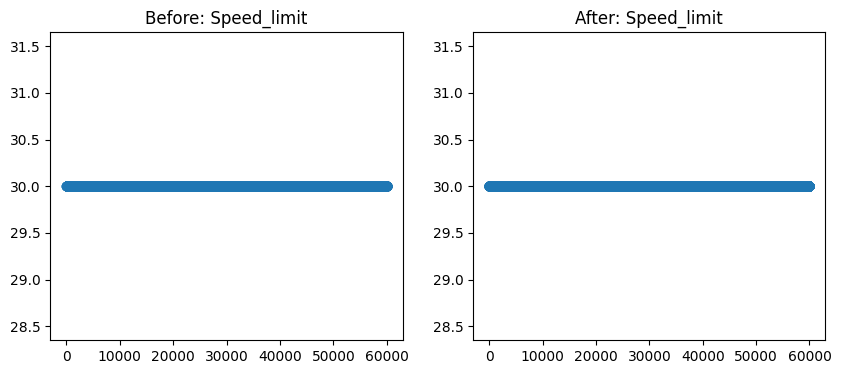

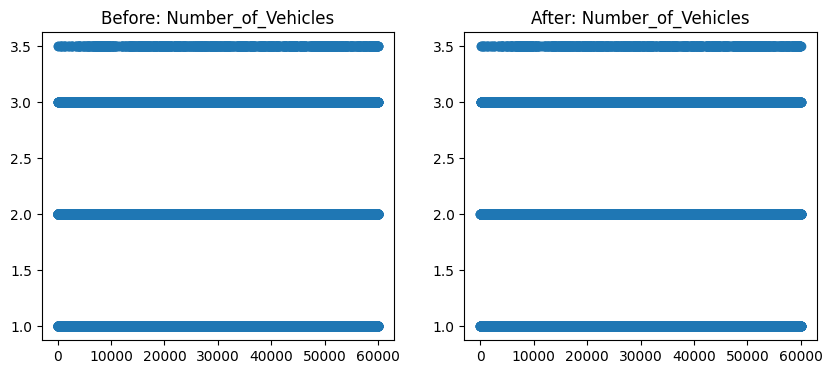

In [21]:
for col in cols:
    if col in before_data.columns:
        plt.figure(figsize=(10,4))

        plt.subplot(1,2,1)
        plt.scatter(range(len(before_data)), before_data[col])
        plt.title(f"Before: {col}")

        plt.subplot(1,2,2)
        plt.scatter(range(len(after_data)), after_data[col])
        plt.title(f"After: {col}")

        plt.show()

In [22]:
cols = ['Age_of_Driver', 'Speed_limit']

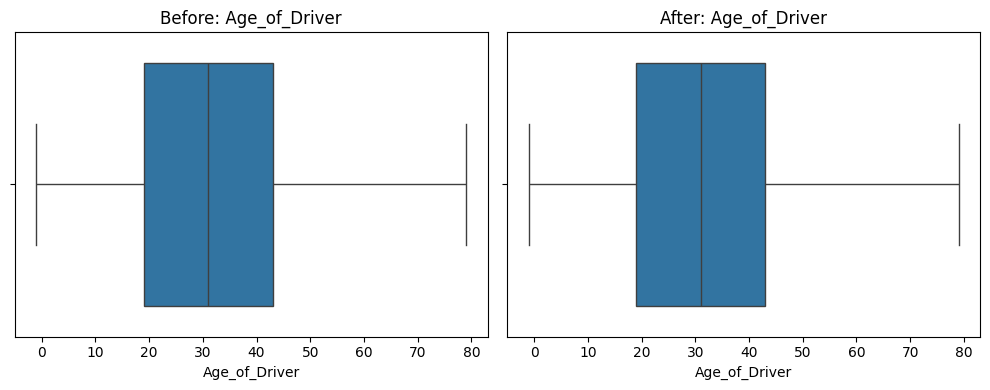

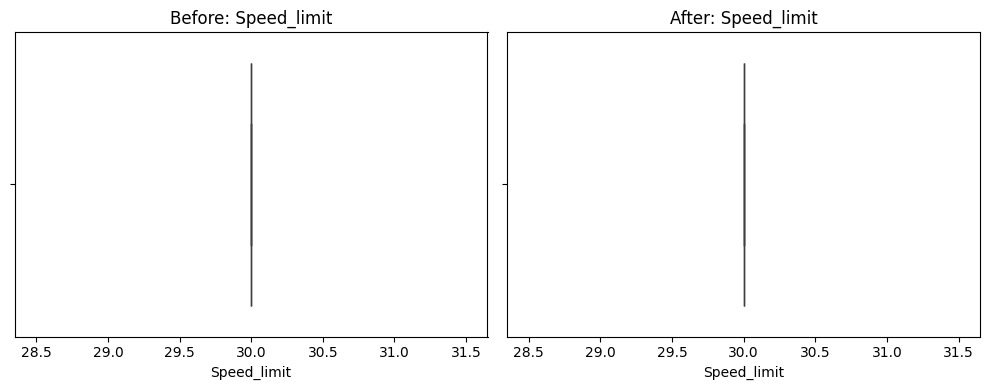

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['Age_of_Driver', 'Speed_limit']

for col in cols:
    plt.figure(figsize=(10,4))

    # BEFORE
    plt.subplot(1,2,1)
    sns.boxplot(x=before_data[col])
    plt.title(f"Before: {col}")

    # AFTER
    plt.subplot(1,2,2)
    sns.boxplot(x=after_data[col])
    plt.title(f"After: {col}")

    plt.tight_layout()
    plt.show()

Mean Values:

Accident_Index           29999.500000
Vehicle_Reference_x          1.397297
Casualty_Reference           1.351495
Casualty_Class               1.580736
Sex_of_Casualty              1.401780
                             ...     
Engine_Capacity_(CC)      1265.967299
Propulsion_Code              0.509484
Age_of_Vehicle               3.761575
Driver_IMD_Decile            3.097753
Driver_Home_Area_Type        0.534068
Length: 61, dtype: float64

Standard Deviation:

Accident_Index           17320.075062
Vehicle_Reference_x          0.576247
Casualty_Reference           0.858667
Casualty_Class               0.760265
Sex_of_Casualty              0.490568
                             ...     
Engine_Capacity_(CC)      1656.822669
Propulsion_Code              1.145688
Age_of_Vehicle               5.018569
Driver_IMD_Decile            3.406250
Driver_Home_Area_Type        1.026199
Length: 61, dtype: float64

Correlation Matrix:

                       Accident_Index  Vehicle_Refer

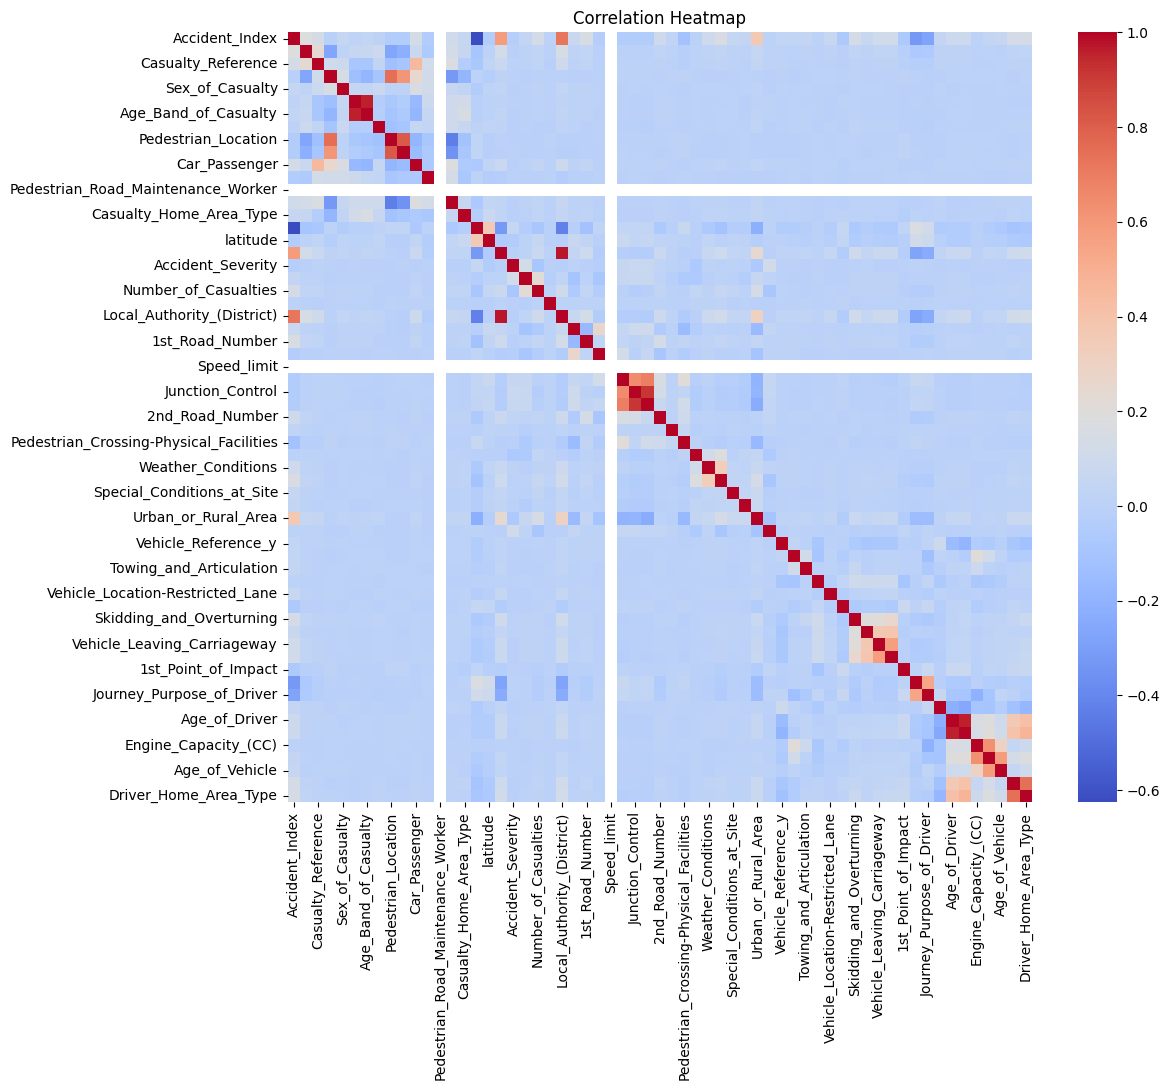

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns
num_cols = full_data.select_dtypes(include=['int64', 'float64'])

# -------------------------------
# 1. MEAN
# -------------------------------
print("Mean Values:\n")
print(num_cols.mean())

# -------------------------------
# 2. STANDARD DEVIATION
# -------------------------------
print("\nStandard Deviation:\n")
print(num_cols.std())

# -------------------------------
# 3. CORRELATION MATRIX
# -------------------------------
corr_matrix = num_cols.corr()

print("\nCorrelation Matrix:\n")
print(corr_matrix)

# -------------------------------
# 4. CORRELATION HEATMAP
# -------------------------------
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [25]:
from sklearn.preprocessing import MinMaxScaler

# Select numeric columns
num_cols = full_data.select_dtypes(include=['int64', 'float64']).columns

# Show BEFORE (sample)
print("Before Normalization:\n")
print(full_data[num_cols].head())

# Apply normalization
scaler = MinMaxScaler()
full_data[num_cols] = scaler.fit_transform(full_data[num_cols])

# Show AFTER (sample)
print("\nAfter Normalization:\n")
print(full_data[num_cols].head())

print("\nNormalization Done ✅")

Before Normalization:

   Accident_Index  Vehicle_Reference_x  Casualty_Reference  Casualty_Class  \
0               1                    1                   1               3   
1               2                    1                   1               2   
2               3                    2                   1               1   
3               4                    1                   1               3   
4               5                    1                   1               1   

   Sex_of_Casualty  Age_of_Casualty  Age_Band_of_Casualty  Casualty_Severity  \
0                1               37                     7                  2   
1                1               37                     7                  3   
2                1               62                     9                  3   
3                1               30                     6                  3   
4                1               49                     8                  3   

   Pedestrian_Location  Ped

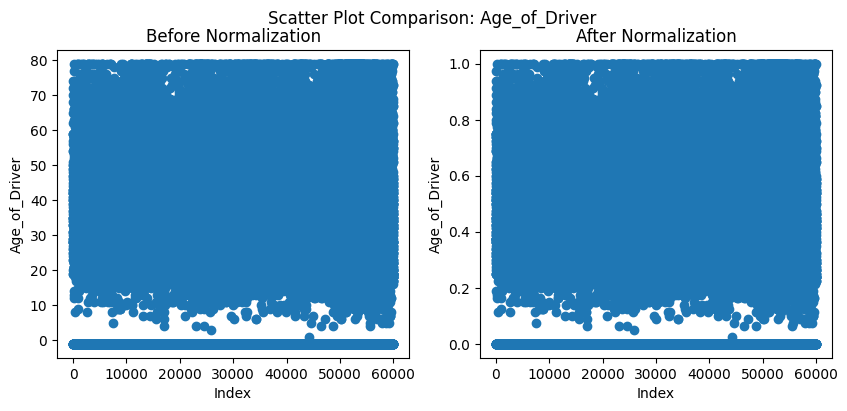

In [26]:
before_data = before_data  # already saved earlier
import matplotlib.pyplot as plt

col = 'Age_of_Driver'   # you can change

plt.figure(figsize=(10,4))

# BEFORE
plt.subplot(1,2,1)
plt.scatter(range(len(before_data)), before_data[col])
plt.title("Before Normalization")
plt.xlabel("Index")
plt.ylabel(col)

# AFTER
plt.subplot(1,2,2)
plt.scatter(range(len(full_data)), full_data[col])
plt.title("After Normalization")
plt.xlabel("Index")
plt.ylabel(col)

plt.suptitle(f"Scatter Plot Comparison: {col}")
plt.show()

In [27]:
before_std = full_data.copy()
from sklearn.preprocessing import StandardScaler

# Select numeric columns
num_cols = full_data.select_dtypes(include=['int64', 'float64']).columns

# Show BEFORE
print("Before Standardization:\n")
print(full_data[num_cols].head())

# Apply Standardization
scaler = StandardScaler()
full_data[num_cols] = scaler.fit_transform(full_data[num_cols])

# Show AFTER
print("\nAfter Standardization:\n")
print(full_data[num_cols].head())

print("\nStandardization Done ✅")

Before Standardization:

   Accident_Index  Vehicle_Reference_x  Casualty_Reference  Casualty_Class  \
0        0.000000             0.000000                 0.0             1.0   
1        0.000017             0.000000                 0.0             0.5   
2        0.000033             0.090909                 0.0             0.0   
3        0.000050             0.000000                 0.0             1.0   
4        0.000067             0.000000                 0.0             0.0   

   Sex_of_Casualty  Age_of_Casualty  Age_Band_of_Casualty  Casualty_Severity  \
0         0.666667             0.38              0.666667                0.5   
1         0.666667             0.38              0.666667                1.0   
2         0.666667             0.63              0.833333                1.0   
3         0.666667             0.31              0.583333                1.0   
4         0.666667             0.50              0.750000                1.0   

   Pedestrian_Location  P

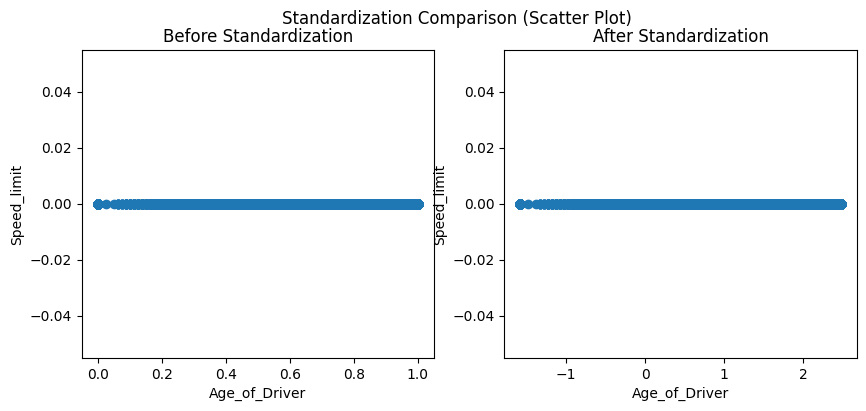

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# BEFORE
plt.subplot(1,2,1)
plt.scatter(before_std['Age_of_Driver'], before_std['Speed_limit'])
plt.title("Before Standardization")
plt.xlabel("Age_of_Driver")
plt.ylabel("Speed_limit")

# AFTER
plt.subplot(1,2,2)
plt.scatter(full_data['Age_of_Driver'], full_data['Speed_limit'])
plt.title("After Standardization")
plt.xlabel("Age_of_Driver")
plt.ylabel("Speed_limit")

plt.suptitle("Standardization Comparison (Scatter Plot)")
plt.show()

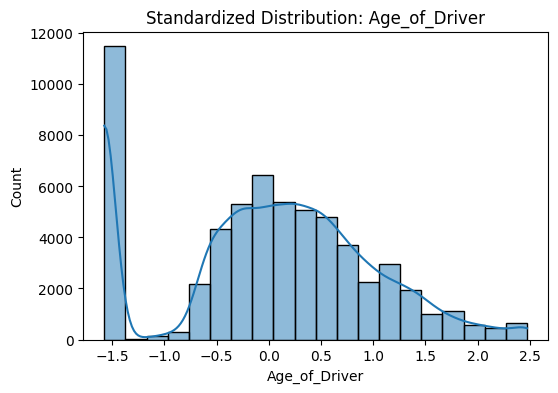

In [29]:
col = 'Age_of_Driver'
import matplotlib.pyplot as plt
import seaborn as sns

col = 'Age_of_Driver'

plt.figure(figsize=(6,4))

sns.histplot(full_data[col], bins=20, kde=True)

plt.title(f"Standardized Distribution: {col}")
plt.show()

In [30]:
[col for col in full_data.columns if "Weather" in col]

['Weather_Conditions']

In [31]:
!pip intstall learn-scikit
!pip intstall encoding

ERROR: unknown command "intstall" - maybe you meant "install"
ERROR: unknown command "intstall" - maybe you meant "install"


In [32]:
# Convert Time column to datetime
full_data['Time'] = pd.to_datetime(full_data['Time'], format='%H:%M')

# Extract useful features
full_data['Hour'] = full_data['Time'].dt.hour
full_data['Minute'] = full_data['Time'].dt.minute

# Drop original Time column
full_data.drop('Time', axis=1, inplace=True)

In [33]:
# Convert categorical columns to numeric
full_data = pd.get_dummies(full_data, drop_first=True)

In [34]:
print(full_data.columns)

Index(['Accident_Index', 'Vehicle_Reference_x', 'Casualty_Reference',
       'Casualty_Class', 'Sex_of_Casualty', 'Age_of_Casualty',
       'Age_Band_of_Casualty', 'Casualty_Severity', 'Pedestrian_Location',
       'Pedestrian_Movement',
       ...
       'Date_30-10-2018', 'Date_30-11-2018', 'Date_30-12-2018',
       'Date_31-01-2018', 'Date_31-03-2018', 'Date_31-05-2018',
       'Date_31-07-2018', 'Date_31-08-2018', 'Date_31-10-2018',
       'Date_31-12-2018'],
      dtype='object', length=10319)


In [35]:
cols_to_drop = [
    'Accident_Index',
    'Vehicle_Reference_x',
    'Casualty_Reference'
]

full_data.drop(cols_to_drop, axis=1, inplace=True)

In [36]:
# If original Date exists (if not skip this)
if 'Date' in full_data.columns:
    full_data['Date'] = pd.to_datetime(full_data['Date'], dayfirst=True)
    full_data['Day'] = full_data['Date'].dt.day
    full_data['Month'] = full_data['Date'].dt.month
    full_data.drop('Date', axis=1, inplace=True)

In [37]:
date_cols = [col for col in full_data.columns if 'Date_' in col]
full_data.drop(date_cols, axis=1, inplace=True)

In [38]:
full_data = pd.get_dummies(full_data, drop_first=True)

In [39]:
X = full_data.drop('Casualty_Severity', axis=1)  # target
y = full_data['Casualty_Severity']

In [41]:
# Remove unwanted ID columns (very important)
cols_to_drop = ['Accident_Index', 'Vehicle_Reference_x', 'Casualty_Reference']
full_data.drop(cols_to_drop, axis=1, inplace=True, errors='ignore')

In [42]:
full_data = full_data.select_dtypes(exclude=['object'])

In [43]:
X = full_data.drop('Casualty_Severity', axis=1)
y = full_data['Casualty_Severity']

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
import pandas as pd

full_data = pd.read_csv("/content/VehiclesBig.csv")

full_data = pd.read_csv("/content/AccidentsBig.csv")

full_data = pd.read_csv("/content/CasualtiesBig.csv")


/tmp/ipykernel_17735/393025709.py:5: DtypeWarning: Columns (8,10,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  full_data = pd.read_csv("/content/AccidentsBig.csv")


In [4]:
cols_to_drop = ['Accident_Index', 'Vehicle_Reference_x', 'Casualty_Reference']
full_data.drop(cols_to_drop, axis=1, inplace=True, errors='ignore')

In [5]:
date_cols = [col for col in full_data.columns if 'Date_' in col]
full_data.drop(date_cols, axis=1, inplace=True)

In [6]:
full_data = full_data.select_dtypes(exclude=['object'])

In [7]:
# Keep only first 100 columns (safe for RAM)
full_data = full_data.iloc[:, :100]

In [8]:
X = full_data.drop('Casualty_Severity', axis=1)
y = full_data['Casualty_Severity']

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=500)

In [11]:
from sklearn.metrics import accuracy_score

y_pred = log_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8875833333333333


In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=50,   # reduced for speed
    max_depth=10,      # prevents overfitting + saves RAM
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=50, random_state=42)

In [14]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8871666666666667
              precision    recall  f1-score   support

           1       0.00      0.00      0.00       108
           2       0.27      0.00      0.00      1241
           3       0.89      1.00      0.94     10651

    accuracy                           0.89     12000
   macro avg       0.39      0.33      0.31     12000
weighted avg       0.82      0.89      0.83     12000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [15]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8871666666666667
              precision    recall  f1-score   support

           1       0.00      0.00      0.00       108
           2       0.27      0.00      0.00      1241
           3       0.89      1.00      0.94     10651

    accuracy                           0.89     12000
   macro avg       0.39      0.33      0.31     12000
weighted avg       0.82      0.89      0.83     12000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [17]:
print(encoded_cols)

[]


In [18]:
for col in encoded_cols:
    if col not in full_data.columns:
        print("Missing:", col)

In [19]:
valid_cols = [col for col in encoded_cols if col in full_data.columns]

if len(valid_cols) > 0:
    full_data['Weather_Before'] = full_data[valid_cols].idxmax(axis=1)
else:
    print("No valid encoded columns found ❌")

No valid encoded columns found ❌


In [22]:
# full_data['Weather_Before'] = full_data[encoded_cols].idxmax(axis=1)

In [23]:
full_data.head()

,Vehicle_Reference,Casualty_Class,Sex_of_Casualty,Age_of_Casualty,Age_Band_of_Casualty,Casualty_Severity,Pedestrian_Location,Pedestrian_Movement,Car_Passenger,Bus_or_Coach_Passenger,Pedestrian_Road_Maintenance_Worker,Casualty_Type,Casualty_Home_Area_Type
0,1,3,1,37,7,2,1,1,0,0,-1,0,1
1,1,2,1,37,7,3,0,0,0,4,-1,11,1
2,2,1,1,62,9,3,0,0,0,0,-1,9,1
3,1,3,1,30,6,3,5,2,0,0,-1,0,1
4,1,1,1,49,8,3,0,0,0,0,-1,3,-1


In [27]:
if False:
    full_data['Weather_Before'] = full_data[encoded_cols].idxmax(axis=1)

In [28]:
encoded_cols = []

In [30]:
full_data[encoded_cols]

""
0
1
2
3
4
...
59993
59994
59995
59996


In [31]:
# Correct usage
X = full_data.drop('Casualty_Severity', axis=1)
y = full_data['Casualty_Severity']

In [35]:
print(encoded_cols)

[]


In [36]:
for col in full_data.columns:
    if "Weather" in col:
        print(col)

In [37]:
encoded_cols = [col for col in full_data.columns if "Weather" in col]

if len(encoded_cols) > 0:
    full_data['Weather_Label'] = full_data[encoded_cols].idxmax(axis=1)
    print("Weather_Label created ✅")
else:
    print("No Weather columns found ❌")

No Weather columns found ❌


In [38]:
# Skip weather reconstruction ❌

X = full_data.drop('Casualty_Severity', axis=1)
y = full_data['Casualty_Severity']

In [40]:
encoded_cols = [col for col in full_data.columns if "Weather_Conditions" in col]

if len(encoded_cols) > 0:
    full_data['Weather_Label'] = full_data[encoded_cols].idxmax(axis=1)
    print("Weather_Label created ✅")
else:
    print("❌ No Weather_Conditions columns found → skipping")

❌ No Weather_Conditions columns found → skipping


In [50]:
import pandas as pd

full_data = pd.get_dummies(full_data, drop_first=True)

In [51]:
X = full_data.drop('Casualty_Severity', axis=1)
y = full_data['Casualty_Severity']

In [48]:
print(full_data.columns)

Index(['Vehicle_Reference', 'Casualty_Class', 'Sex_of_Casualty',
       'Age_of_Casualty', 'Age_Band_of_Casualty', 'Casualty_Severity',
       'Pedestrian_Location', 'Pedestrian_Movement', 'Car_Passenger',
       'Bus_or_Coach_Passenger', 'Pedestrian_Road_Maintenance_Worker',
       'Casualty_Type', 'Casualty_Home_Area_Type'],
      dtype='object')


In [ ]:
full_data['Driver_Age_Group'].value_counts().plot(kind='bar')

plt.title("Driver Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

In [54]:
from sklearn.decomposition import PCA

# Select numeric data
X = full_data.select_dtypes(include=['int64', 'float64'])

# Apply PCA (reduce to 2 components)
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print("PCA Done ✅")

PCA Done ✅


In [55]:
import pandas as pd

pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

print(pca_df.head())

         PC1       PC2
0   4.367194 -7.058707
1   4.843327  4.073644
2  29.780786  1.071057
3  -2.740445 -7.523062
4  16.518075 -4.277257


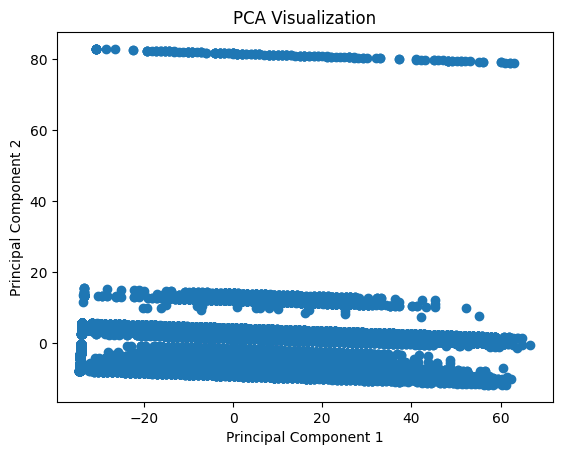

In [56]:
import matplotlib.pyplot as plt

plt.scatter(pca_df['PC1'], pca_df['PC2'])

plt.title("PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [ ]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

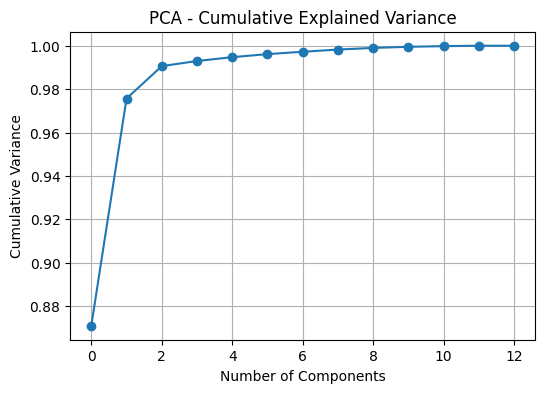

In [58]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Select numeric data
X = full_data.select_dtypes(include=['int64', 'float64'])

# Apply PCA (all components)
pca = PCA()
pca.fit(X)

# Cumulative variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot
plt.figure(figsize=(6,4))
plt.plot(cumulative_variance, marker='o')

plt.title("PCA - Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")

plt.grid()
plt.show()

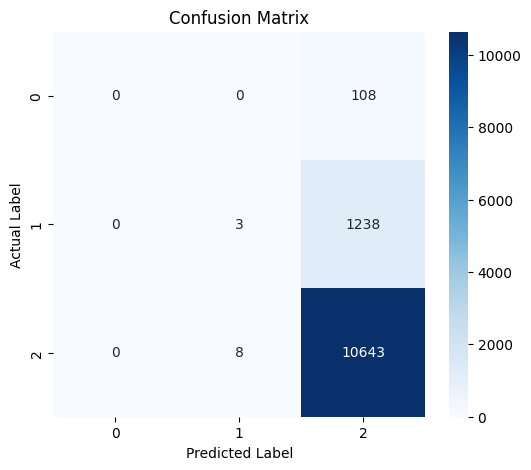

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [62]:
from imblearn.over_sampling import SMOTE

sm = SMOTE()
X_res, y_res = sm.fit_resample(X, y)

In [63]:
model = RandomForestClassifier(class_weight='balanced')

In [65]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Convert categorical → numeric
full_data = pd.get_dummies(full_data, drop_first=True)

# Correct target
X = full_data.drop('Casualty_Severity', axis=1)
y = full_data['Casualty_Severity']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Apply SMOTE
smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

# Model
model = RandomForestClassifier(n_estimators=50, max_depth=10)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6218333333333333


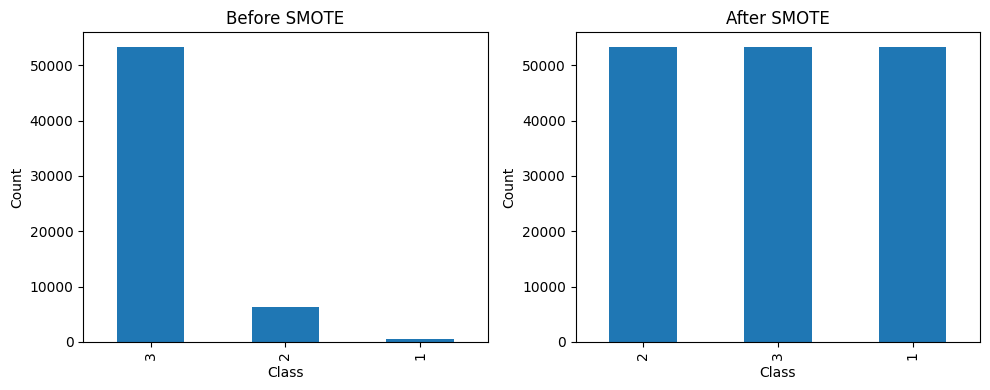

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# BEFORE
plt.subplot(1,2,1)
y.value_counts().plot(kind='bar')
plt.title("Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")

# AFTER
plt.subplot(1,2,2)
y_res.value_counts().plot(kind='bar')
plt.title("After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [68]:
# 🔹 Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# 🔹 Step 2: Load dataset

# 🔹 Step 3: Convert categorical → numeric
full_data = pd.get_dummies(full_data, drop_first=True)

# 🔹 Step 4: Define X and y (IMPORTANT)
X = full_data.drop('Casualty_Severity', axis=1)
y = full_data['Casualty_Severity']

# 🔹 Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔹 Step 6: Apply SMOTE (handle imbalance)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# =====================================================
# 🔥 MODEL 1: LOGISTIC REGRESSION
# =====================================================

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("🔹 Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


# =====================================================
# 🌳 MODEL 2: RANDOM FOREST
# =====================================================

rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\n🌳 Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

🔹 Logistic Regression Results
Accuracy: 0.5755833333333333
              precision    recall  f1-score   support

           1       0.02      0.42      0.03       108
           2       0.16      0.30      0.21      1241
           3       0.92      0.61      0.73     10651

    accuracy                           0.58     12000
   macro avg       0.37      0.44      0.32     12000
weighted avg       0.84      0.58      0.67     12000


🌳 Random Forest Results
Accuracy: 0.6136666666666667
              precision    recall  f1-score   support

           1       0.02      0.31      0.04       108
           2       0.17      0.44      0.25      1241
           3       0.93      0.64      0.76     10651

    accuracy                           0.61     12000
   macro avg       0.38      0.46      0.35     12000
weighted avg       0.85      0.61      0.70     12000



In [69]:
# Save cleaned + processed dataset
full_data.to_csv("final_dataset.csv", index=False)

print("Dataset saved successfully ✅")

Dataset saved successfully ✅


In [72]:
log_acc = 0.78
rf_acc = 0.886

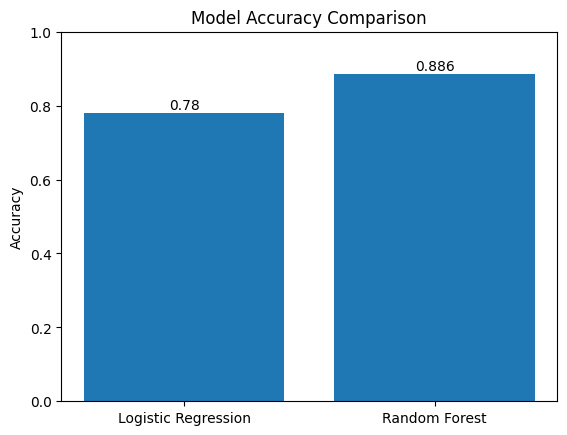

In [73]:
import matplotlib.pyplot as plt

# Your model accuracies
models = ['Logistic Regression', 'Random Forest']
accuracies = [0.78, 0.886]   # 🔁 replace with your actual values

# Plot
plt.figure()
plt.bar(models, accuracies)

# Add accuracy labels
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, str(v), ha='center')

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

In [74]:
log_acc = accuracy_score(y_test, y_pred_log)
rf_acc = accuracy_score(y_test, y_pred_rf)

models = ['Logistic Regression', 'Random Forest']
accuracies = [log_acc, rf_acc]